## Depression Dataset: Clustering Analysis and Bayesian Network

**Depression Dataset** ([Kaggle — anthonytherrien/depression-dataset](https://www.kaggle.com/datasets/anthonytherrien/depression-dataset)).

Dependencies included
* **`pgmpy`**: Probabilistic Graphical Models (Bayesian Networks, structure & parameter learning, inference).
* **`kmodes`**: Huang's K-Modes / K-Prototypes for categorical and mixed data.
* **`gower`**: Gower distance for mixed-type proximity matrices.
* **`kneed`**:  automatic knee-detection (for DBSCAN ε and PCA components).
* **`shap`**:  Shapley-value explanations for the surrogate model.
* **`yellowbrick`**:  clean elbow / silhouette visualizers.

In [1]:
import os, sys, warnings, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OrdinalEncoder
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (silhouette_score, calinski_harabasz_score, davies_bouldin_score,
                             adjusted_rand_score, rand_score, fowlkes_mallows_score,
                             f1_score, accuracy_score, confusion_matrix, classification_report)
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split

# scipy / hierarchy
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import pdist, squareform
from scipy import stats

# mixed-data / categorical clustering
from kmodes.kmodes import KModes
from kmodes.kprototypes import KPrototypes
import gower

# knee detection
from kneed import KneeLocator

# Bayesian Networks (pgmpy)

from pgmpy.models import DiscreteBayesianNetwork

# Structure learning
from pgmpy.estimators import (HillClimbSearch, BIC, K2, AIC, BDeu, MaximumLikelihoodEstimator, BayesianEstimator)

# Parameter estimation #from pgmpy.estimators import ( )

# Inference
from pgmpy.inference import VariableElimination
import networkx as nx

# explainability
import shap

/home/nigus-haile/anaconda3/envs/lab_exercises/lib/python3.14/site-packages/pgmpy/estimators/__init__.py:4: FutureWarning: `pgmpy.estimators.StructureScore` is deprecated and will be removed in a future release. Use `pgmpy.structure_score` instead.
  from .StructureScore import (


In [2]:
# reproducibility
warnings.filterwarnings("ignore")
SEED = 42
random.seed(SEED); np.random.seed(SEED)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
PAL = ['#2E86AB', '#E63946', '#06A77D', '#F4A261', '#9D4EDD',
       '#FB6F92', '#264653', '#E9C46A', '#118AB2', '#EF476F']
sns.set_palette(PAL)

## Loading the dataset

In [3]:
# Dataset
dataset_path = "/media/nigus-haile/Local/EDU/milano_bicocca/2nd_semester/Unsupervised/Exam/final_project/depression_dataset"
file_name    = "depression_data.csv"
file_path    = os.path.join(dataset_path, file_name)

# Robust load: try the configured path, then fall back to common alternatives.
candidate_paths = [
    file_path,
    "depression_data.csv",
    "./depression_data.csv",
    "/content/depression_data.csv",
]
for p in candidate_paths:
    if os.path.exists(p):
        file_path = p
        break

print(f"Reading from: {file_path}")
df_full = pd.read_csv(file_path)
print(f"Loaded shape: {df_full.shape}")
df_full.head()


Reading from: /media/nigus-haile/Local/EDU/milano_bicocca/2nd_semester/Unsupervised/Exam/final_project/depression_dataset/depression_data.csv
Loaded shape: (413768, 16)


,Name,Age,Marital Status,Education Level,Number of Children,Smoking Status,Physical Activity Level,Employment Status,Income,Alcohol Consumption,Dietary Habits,Sleep Patterns,History of Mental Illness,History of Substance Abuse,Family History of Depression,Chronic Medical Conditions
0,Christine Barker,31,Married,Bachelor's Degree,2,Non-smoker,Active,Unemployed,26265.67,Moderate,Moderate,Fair,Yes,No,Yes,Yes
1,Jacqueline Lewis,55,Married,High School,1,Non-smoker,Sedentary,Employed,42710.36,High,Unhealthy,Fair,Yes,No,No,Yes
2,Shannon Church,78,Widowed,Master's Degree,1,Non-smoker,Sedentary,Employed,125332.79,Low,Unhealthy,Good,No,No,Yes,No
3,Charles Jordan,58,Divorced,Master's Degree,3,Non-smoker,Moderate,Unemployed,9992.78,Moderate,Moderate,Poor,No,No,No,No
4,Michael Rich,18,Single,High School,0,Non-smoker,Sedentary,Unemployed,8595.08,Low,Moderate,Fair,Yes,No,Yes,Yes


In [4]:
# Overview of the dataset
print(df_full.info())


<class 'pandas.DataFrame'>
RangeIndex: 413768 entries, 0 to 413767
Data columns (total 16 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Name                          413768 non-null  str    
 1   Age                           413768 non-null  int64  
 2   Marital Status                413768 non-null  str    
 3   Education Level               413768 non-null  str    
 4   Number of Children            413768 non-null  int64  
 5   Smoking Status                413768 non-null  str    
 6   Physical Activity Level       413768 non-null  str    
 7   Employment Status             413768 non-null  str    
 8   Income                        413768 non-null  float64
 9   Alcohol Consumption           413768 non-null  str    
 10  Dietary Habits                413768 non-null  str    
 11  Sleep Patterns                413768 non-null  str    
 12  History of Mental Illness     413768 non-null  str    


In [5]:
# Descriptive statistics for numerical columns
numerical_data = df_full[['Age', 'Number of Children', 'Income']]
numerical_data.describe(include='all').T


,count,mean,std,min,25%,50%,75%,max
Age,413768.0,49.000713,18.158759,18.00,33.00,49.000,65.0,80.00
Number of Children,413768.0,1.298972,1.237054,0.00,0.00,1.000,2.0,4.00
Income,413768.0,50661.707971,40624.100565,0.41,21001.03,37520.135,76616.3,209995.22


---
## Data Preprocessing

### Dataset description

The dataset contains **413,768 rows** describing socio-economic, lifestyle and
medical attributes of adults, together with two binarymental-health labels.
We start with a manual classification of the variables into **numerical** /
**ordinal** / **nominal** — this is *crucial* because every clustering algorithm
below expects an appropriate distance / dissimilarity measure.

| Variable | Type | Range / Categories |
|---|---|---|
| `Name` | Identifier | (dropped) |
| `Age` | numerical (years) | 18 – 80 |
| `Marital Status` | nominal | Single, Married, Divorced, Widowed |
| `Education Level` | **ordinal** | High School < Associate < Bachelor's < Master's < PhD |
| `Number of Children` | numerical | 0 – 4 |
| `Smoking Status` | nominal | Non-smoker, Former, Current |
| `Physical Activity Level` | **ordinal** | Sedentary < Moderate < Active |
| `Employment Status` | nominal | Employed, Unemployed |
| `Income` | numerical (USD) | continuous |
| `Alcohol Consumption` | **ordinal** | Low < Moderate < High |
| `Dietary Habits` | **ordinal** | Unhealthy < Moderate < Healthy |
| `Sleep Patterns` | **ordinal** | Poor < Fair < Good |
| `History of Substance Abuse` | binary| Yes / No |
| `Family History of Depression` | binary| Yes / No (**target #2**) |
| `Chronic Medical Conditions` | binary| Yes / No |
| `History of Mental Illness` | binary| Yes / No (**primary target**) |

> **Choice of dissimilarity matters.** Because we have *mixed* variable types
> (numerical + ordinal + nominal), Euclidean distance applied to one-hot
> encodings would be biased.
> We therefore compute **Gower's distance**, which combines a
> per-attribute metric appropriate to the variable type and produces a single
> dissimilarity in `[0,1]`. For K-Prototypes we keep the raw mixed table and
> let the algorithm combine Euclidean + matching internally; for K-Modes we
> categorise everything ('Age` and `Income`).

In [6]:
# Drop the identifier column (Name)
if 'Name' in df_full.columns:
    df_full = df_full.drop(columns=['Name'])

# Standardise column names (no spaces) for easier downstream access.
df_full.columns = [c.replace(' ', '_') for c in df_full.columns]
print("Columns:", list(df_full.columns))
df_full.head()


Columns: ['Age', 'Marital_Status', 'Education_Level', 'Number_of_Children', 'Smoking_Status', 'Physical_Activity_Level', 'Employment_Status', 'Income', 'Alcohol_Consumption', 'Dietary_Habits', 'Sleep_Patterns', 'History_of_Mental_Illness', 'History_of_Substance_Abuse', 'Family_History_of_Depression', 'Chronic_Medical_Conditions']


,Age,Marital_Status,Education_Level,Number_of_Children,Smoking_Status,Physical_Activity_Level,Employment_Status,Income,Alcohol_Consumption,Dietary_Habits,Sleep_Patterns,History_of_Mental_Illness,History_of_Substance_Abuse,Family_History_of_Depression,Chronic_Medical_Conditions
0,31,Married,Bachelor's Degree,2,Non-smoker,Active,Unemployed,26265.67,Moderate,Moderate,Fair,Yes,No,Yes,Yes
1,55,Married,High School,1,Non-smoker,Sedentary,Employed,42710.36,High,Unhealthy,Fair,Yes,No,No,Yes
2,78,Widowed,Master's Degree,1,Non-smoker,Sedentary,Employed,125332.79,Low,Unhealthy,Good,No,No,Yes,No
3,58,Divorced,Master's Degree,3,Non-smoker,Moderate,Unemployed,9992.78,Moderate,Moderate,Poor,No,No,No,No
4,18,Single,High School,0,Non-smoker,Sedentary,Unemployed,8595.08,Low,Moderate,Fair,Yes,No,Yes,Yes


In [7]:
# check missing value
miss = df_full.isna().sum()
print("Missing values per column:\n")
print(miss[miss > 0] 
      if miss.sum() 
      else miss)
print(f"\n Total number of missing values: {df_full.isna().sum().sum()}")


Missing values per column:

Age                             0
Marital_Status                  0
Education_Level                 0
Number_of_Children              0
Smoking_Status                  0
Physical_Activity_Level         0
Employment_Status               0
Income                          0
Alcohol_Consumption             0
Dietary_Habits                  0
Sleep_Patterns                  0
History_of_Mental_Illness       0
History_of_Substance_Abuse      0
Family_History_of_Depression    0
Chronic_Medical_Conditions      0
dtype: int64

 Total number of missing values: 0


In [8]:
# Duplicate records
num_duplicate = df_full.duplicated().sum()
print(f"Number of fully duplicated rows: {num_duplicate}  ({100*num_duplicate/len(df_full):.2f}%)")


Number of fully duplicated rows: 0  (0.00%)


### Variable-type declaration

We list the variables grouped by type. This dictionary is **the single source
of truth** referenced by every preprocessing block below.

In [9]:
# Authoritative variable typing
numerical  = ['Age', 'Income', 'Number_of_Children']

ordinal    = {
    'Education_Level':         ['High School', "Associate Degree",
                                "Bachelor's Degree", "Master's Degree", 'PhD'],
    'Physical_Activity_Level': ['Sedentary', 'Moderate', 'Active'],
    'Alcohol_Consumption':     ['Low', 'Moderate', 'High'],
    'Dietary_Habits':          ['Unhealthy', 'Moderate', 'Healthy'],
    'Sleep_Patterns':          ['Poor', 'Fair', 'Good'],
}

nominal    = ['Marital_Status', 'Smoking_Status', 'Employment_Status']

binary= ['History_of_Substance_Abuse', 'Family_History_of_Depression',
              'Chronic_Medical_Conditions', 'History_of_Mental_Illness']

#  every column (except Name, already dropped) appears exactly once.
assert set(df_full.columns) == set(numerical + list(ordinal.keys()) + nominal + binary), \
       "Column-typing mismatch — check column names"

print(f"  numerical : {numerical}")
print(f"  ordinal   : {list(ordinal.keys())}")
print(f"  nominal   : {nominal}")
print(f"  binary: {binary}")


  numerical : ['Age', 'Income', 'Number_of_Children']
  ordinal   : ['Education_Level', 'Physical_Activity_Level', 'Alcohol_Consumption', 'Dietary_Habits', 'Sleep_Patterns']
  nominal   : ['Marital_Status', 'Smoking_Status', 'Employment_Status']
  binary: ['History_of_Substance_Abuse', 'Family_History_of_Depression', 'Chronic_Medical_Conditions', 'History_of_Mental_Illness']


### Sub-sampling for computational tractability

With **413 768** rows × 15 attributes, hierarchical clustering and any pair-wise
distance matrix would require ≈ 170 GB of RAM (the matrix is `O(N²)`). we work on a **stratified sub-sample** with respect to
the primary target — this preserves the class proportion while keeping the
analysis tractable on a workstation. We use **N = 8 000** points: large enough
for stable statistics, small enough for a full Gower matrix (≈ 250 MB).

Note that **the target is used only for stratification**, not as a feature.

In [10]:
# Stratified sub-sample to keep computation tractable while preserving balance.

from sklearn.model_selection import StratifiedShuffleSplit
subsumple_num = 10000


fair_subsample = StratifiedShuffleSplit(n_splits=1, test_size = subsumple_num, random_state=SEED)
_, idx = next(fair_subsample.split(df_full, df_full['History_of_Mental_Illness']))
df_stratified = df_full.iloc[idx].reset_index(drop=True).copy()

print(f"Sub-sampled to {df_stratified.shape[0]} rows, {df_stratified.shape[1]} columns")
print("\nClass balance preserved:")
print("  full  :", df_full['History_of_Mental_Illness'].value_counts(normalize=True).round(3).to_dict())
print("  sample:", df_stratified['History_of_Mental_Illness'].value_counts(normalize=True).round(3).to_dict())


Sub-sampled to 10000 rows, 15 columns

Class balance preserved:
  full  : {'No': 0.696, 'Yes': 0.304}
  sample: {'No': 0.696, 'Yes': 0.304}


### Univariate exploration

We inspect the distribution of every variable separately. The goal is to spot
* impossible values (e.g. negative age),
* heavy class imbalance,
* highly-skewed numerical features that may need a log transform,
* candidate outliers to be removed before clustering.

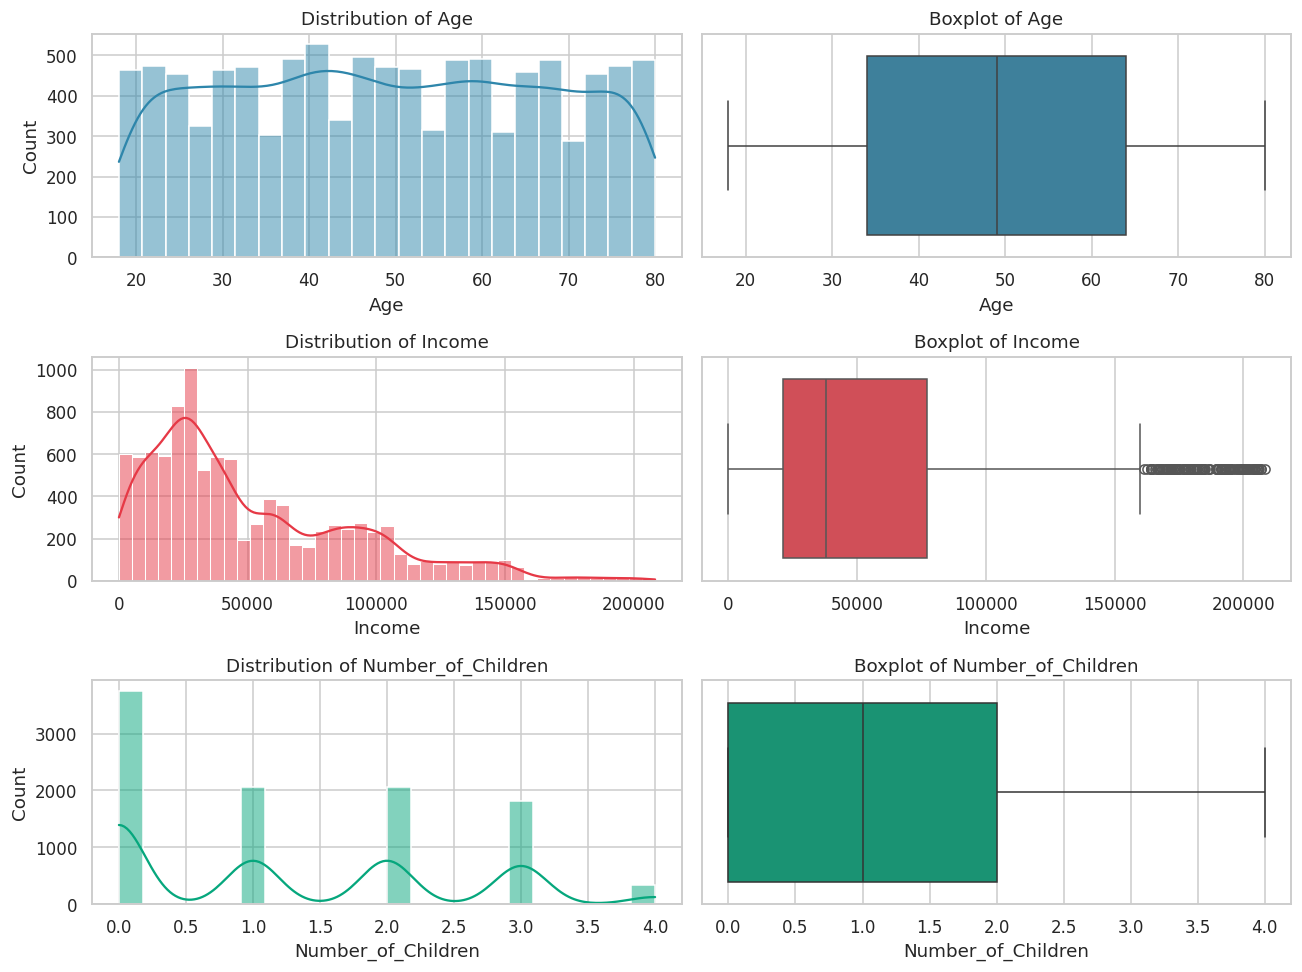

In [11]:
# numerical distributions — histogram + boxplot side by side
fig, axes = plt.subplots(len(numerical), 2, figsize=(12, 3 * len(numerical)))
for i, col in enumerate(numerical):
    sns.histplot(df_stratified[col], kde=True, ax=axes[i, 0], color=PAL[i])
    axes[i, 0].set_title(f"Distribution of {col}")
    sns.boxplot(x=df_stratified[col], ax=axes[i, 1], color=PAL[i])
    axes[i, 1].set_title(f"Boxplot of {col}")
plt.tight_layout(); plt.show()


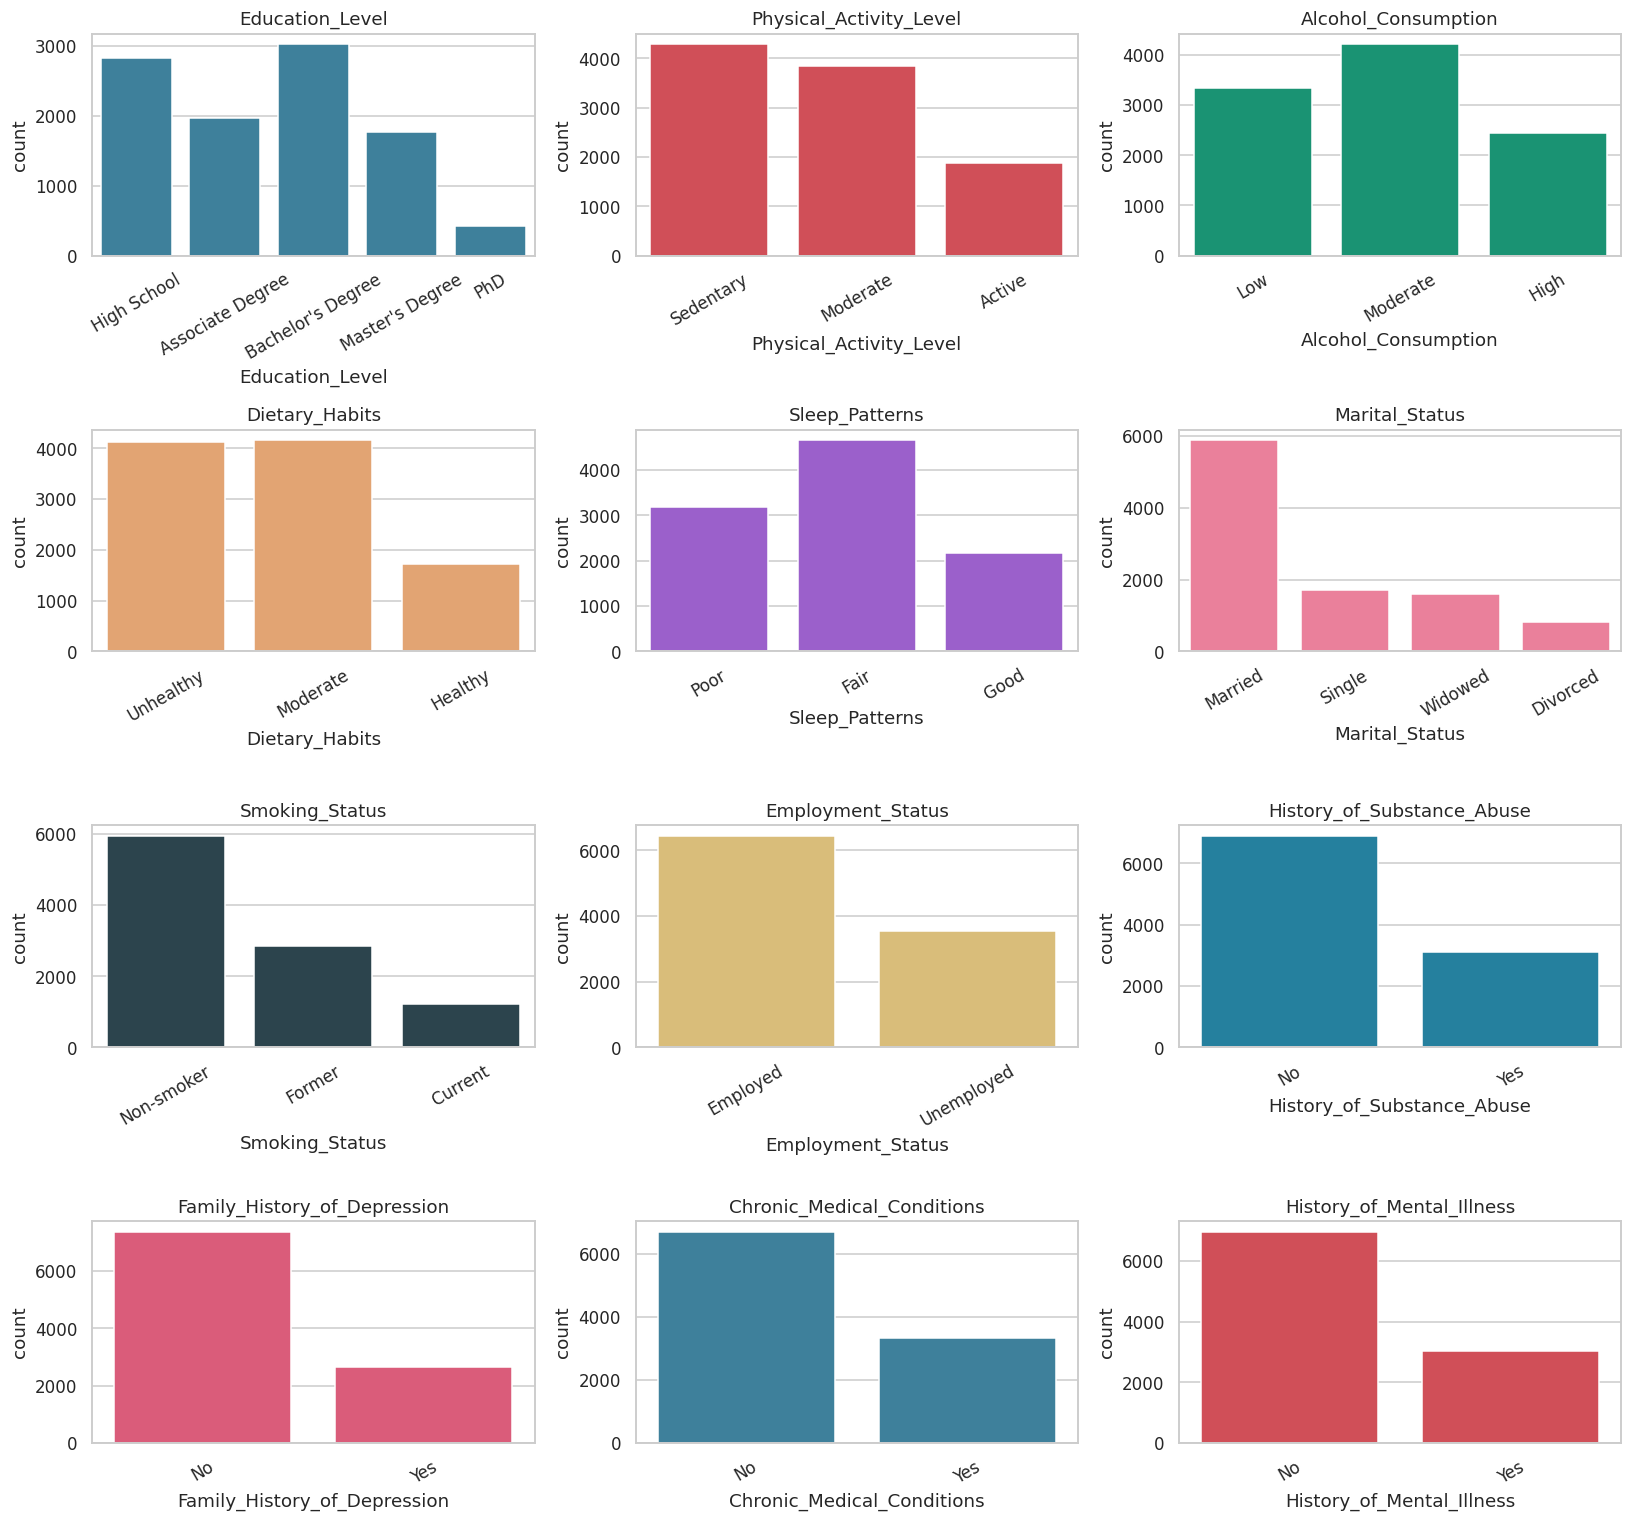

In [12]:
# Categorical distributions — count plots
cat_cols = list(ordinal.keys()) + nominal + binary
n = len(cat_cols)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3.5 * nrows))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    order = ordinal[col] if col in ordinal else df_stratified[col].value_counts().index
    sns.countplot(data=df_stratified, x=col, order=order, ax=axes[i], color=PAL[i % len(PAL)])
    axes[i].set_title(col); axes[i].tick_params(axis='x', rotation=30)
for j in range(i + 1, len(axes)):
    axes[j].axis('off')
plt.tight_layout(); plt.show()


**Observations from EDA.**
* The two mental-health targets are mildly imbalanced (≈ 65 / 35 % for *History of Mental Illness*) but **not pathologically skewed**, both classes are recoverable.
* `Income` exhibits a right-skewed distribution typical of monetary variables, we will apply a `log1p` transform before scaling.
* `Number_of_Children` is heavily-zero-inflated (most respondents have 0 or 1).
* Lifestyle ordinals (`Sleep_Patterns`, `Dietary_Habits`, `Alcohol_Consumption`) are *roughly* uniform, it means the dataset is not artificially polarised.

### Outlier handling

For the **numerical** features we apply an **IQR-based filter**: observations
whose `Income` exceeds the 99th percentile or `Age` is outside `[18, 90]` are
flagged and dropped, they would otherwise dominate Euclidean distances.

In [13]:
# IQR-based outlier removal on Income only (Age and Children are already bounded).
df_stratified_original = df_stratified.copy()

q_low, q_high = df_stratified['Income'].quantile([0.005, 0.995])
mask_income = df_stratified['Income'].between(q_low, q_high)
mask_age    = df_stratified['Age'].between(18, 90)
mask = mask_income & mask_age

print(f"Outliers removed: {(~mask).sum()}  ({100*(~mask).sum()/len(df_stratified):.2f}%)")
df_cleaned = df_stratified.loc[mask].reset_index(drop=True)
print(f"Remaining rows : {len(df_cleaned)}")


Outliers removed: 100  (1.00%)
Remaining rows : 9900


### Encoding strategies

We will create **three parallel views** of the cleaned dataframe, one per family
of algorithms:

| View | Used by | Encoding |
|---|---|---|
| `X_num`  | K-Means++, GMM, PCA, t-SNE (numerical view) | numerical + ordinal kept as integers, nominal one-hot, then `StandardScaler` (mean 0, var 1) |
| `X_mix`  | K-Prototypes, Gower-based hierarchical / DBSCAN | numerical kept *raw* (MinMax-scaled to `[0,1]`), categoricals kept as strings — Gower distance handles the type mix |
| `X_cat`  | K-Modes, Bayesian Network | every variable discretised: numerical → quartile-bins, ordinal → integer-rank, nominal/binary as-is |

This mirrors FinalReport_1's choice to *categorise BMI* and use K-Modes on a
fully-categorical view, plus K-Prototypes on the mixed view..

In [49]:
# (X_num) numerical encoding for distance-based algorithms
df_num = df_cleaned.copy()

# ordinals → integer ranks
for col, order in ordinal.items():
    df_num[col] = pd.Categorical(df_num[col], categories=order, ordered=True).codes

# Binaries → 0 / 1
for col in binary:
    df_num[col] = (df_num[col].astype(str).str.lower() == 'yes').astype(int)

# nominals → one-hot
df_num = pd.get_dummies(df_num, columns=nominal, drop_first=False)

# log1p on Income (right-skewed)
df_num['Income'] = np.log1p(df_num['Income'])

# Separate target from features
target  = 'History_of_Mental_Illness'
second_target = 'Family_History_of_Depression'
y_true   = df_num[target].values
y_fam    = df_num[second_target].values

feature_cols_num = [c for c in df_num.columns if c not in [target]]
X_num_raw = df_num[feature_cols_num].astype(float).values

scaler = StandardScaler()
X_num  = scaler.fit_transform(X_num_raw)
print(f"X_num shape: {X_num.shape}")

print(y_true)



X_num shape: (9900, 20)
[0 1 0 ... 1 0 1]


In [15]:
# (X_mix) — mixed numerical + categorical for K-Prototypes / Gower

df_mix = df_cleaned.copy()
# Standard MinMax for numerical so they live in [0,1] like the categorical
# matching dissimilarity (Huang's gamma assumption).
mm = MinMaxScaler()
df_mix[numerical] = mm.fit_transform(df_mix[numerical])
# Keep categoricals as strings — kmodes / gower both accept object dtype.
for col in list(ordinal.keys()) + nominal + binary:
    df_mix[col] = df_mix[col].astype(str)

X_mix = df_mix.drop(columns=[target, second_target]).copy()
# K-Prototypes needs the indices of categorical columns.
cat_idx = [i for i, c in enumerate(X_mix.columns) if c not in numerical]
print(f"X_mix shape: {X_mix.shape}")
print(f"Categorical column indices for K-Prototypes: {cat_idx}")


X_mix shape: (9900, 13)
Categorical column indices for K-Prototypes: [1, 2, 4, 5, 6, 8, 9, 10, 11, 12]


In [16]:
# (X_cat) — fully-categorical view for K-Modes and the Bayesian Network

df_cat = df_cleaned.copy()
# Discretise numerical features by quartile (4 bins) for an interpretable BN.
def safe_qcut(s, col):
    """qcut that tolerates duplicate quantiles by labelling the actual bins."""
    try:
        binned = pd.qcut(s, q=4,
                         labels=[f"{col}_Q1", f"{col}_Q2", f"{col}_Q3", f"{col}_Q4"])
    except ValueError:
        # Falls back: use as many labels as we get bins.
        binned = pd.qcut(s, q=4, duplicates='drop')
        binned = binned.astype(str).replace(
            dict(zip(binned.cat.categories.astype(str),
                     [f"{col}_Q{i+1}" for i in range(len(binned.cat.categories))])))
    return binned.astype(str)

for col in numerical:
    df_cat[col] = safe_qcut(df_cat[col], col)
# ordinals → string of their rank for readability (kept ordered for the BN)
for col, order in ordinal.items():
    df_cat[col] = pd.Categorical(df_cat[col], categories=order, ordered=True).astype(str)
for col in nominal + binary:
    df_cat[col] = df_cat[col].astype(str)

X_cat = df_cat.drop(columns=[target, second_target]).copy()
print(f"X_cat shape : {X_cat.shape}")
print(f"Example row : {dict(X_cat.iloc[0])}")


X_cat shape : (9900, 13)
Example row : {'Age': 'Age_Q4', 'Marital_Status': 'Widowed', 'Education_Level': "Master's Degree", 'Number_of_Children': 'Number_of_Children_Q1', 'Smoking_Status': 'Non-smoker', 'Physical_Activity_Level': 'Sedentary', 'Employment_Status': 'Employed', 'Income': 'Income_Q4', 'Alcohol_Consumption': 'Moderate', 'Dietary_Habits': 'Moderate', 'Sleep_Patterns': 'Good', 'History_of_Substance_Abuse': 'No', 'Chronic_Medical_Conditions': 'Yes'}


---
## Correlation Analysis and Dimensionality Reduction

### Correlation matrix

we compute the **Pearson correlation matrix** on the
numerical view to spot redundant variables. Because most pairs are
*categorical–categorical*, Pearson is only a rough indicator — for the
Bayesian Network we will reuse the same view but rely on the BIC/AIC
penalty to prune spurious dependencies.

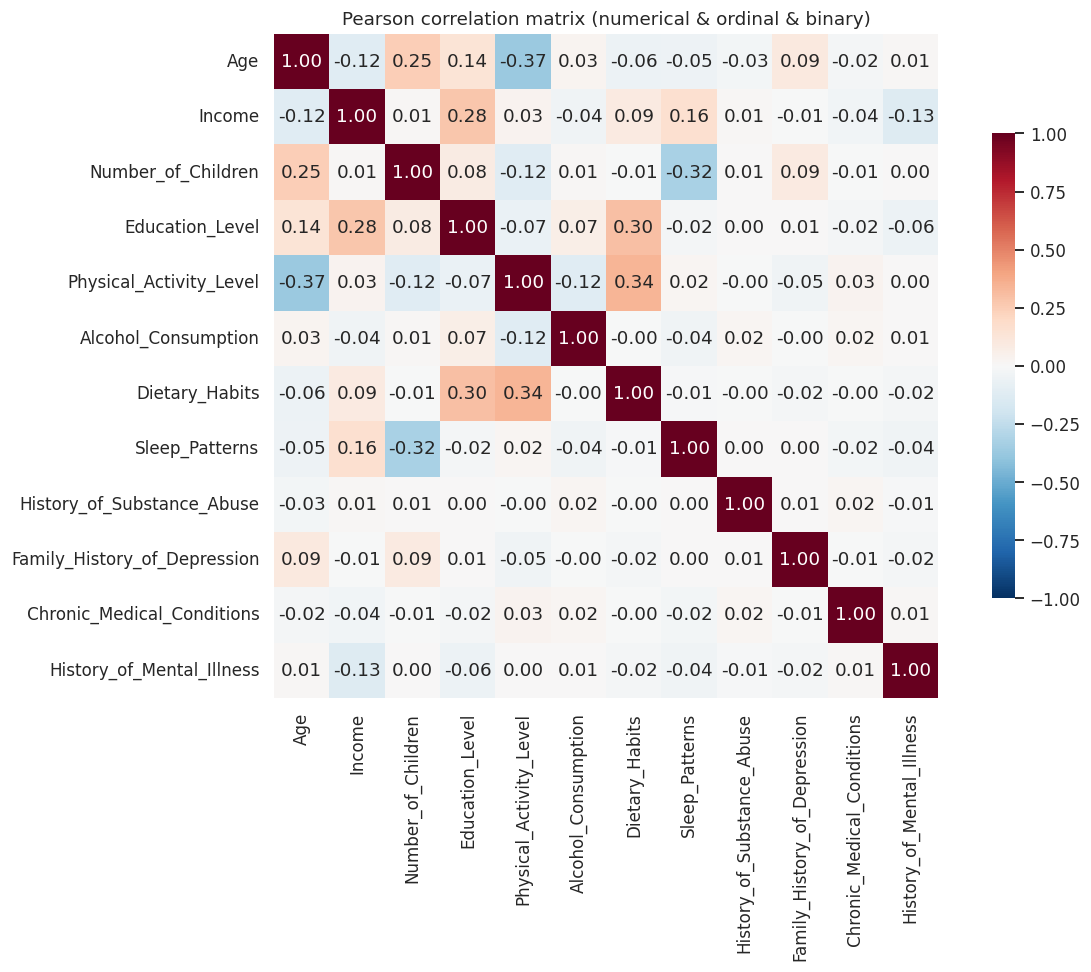

Top correlated pairs (by |Pearson|):
Age                      Physical_Activity_Level      0.369625
Physical_Activity_Level  Dietary_Habits               0.337795
Number_of_Children       Sleep_Patterns               0.322361
Education_Level          Dietary_Habits               0.301116
Income                   Education_Level              0.276080
Age                      Number_of_Children           0.249775
Income                   Sleep_Patterns               0.163086
Age                      Education_Level              0.136845
Income                   History_of_Mental_Illness    0.126641
Age                      Income                       0.121589
dtype: float64


In [17]:
# Pearson correlation heatmap (numerical view, before one-hot of nominals)
core_cols = numerical + list(ordinal.keys()) + binary
df_corr   = df_num[core_cols].copy()
corr      = df_corr.corr(method='pearson')

plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, cbar_kws={'shrink': 0.7})
plt.title("Pearson correlation matrix (numerical & ordinal & binary)")
plt.tight_layout(); plt.show()

# Pairs with |corr| > 0.10 (mild but worth noting)
upper = corr.where(np.triu(np.ones_like(corr, dtype=bool), k=1))
strong = upper.stack().abs().sort_values(ascending=False).head(10)
print("Top correlated pairs (by |Pearson|):")
print(strong)


### PCA and t-SNE: visualizing the data manifold

We project the numerical view to 2-D twice:
* **PCA** preserves global variance, good for outlier inspection.
* **t-SNE** preserves local neighbourhoods, good for cluster discovery.

Both are coloured by the held-out `History_of_Mental_Illness` label only as a
*post-hoc* check (the label is **never** an input).

PCA explained variance ratio: [0.156 0.117] (cumulative = 0.273)


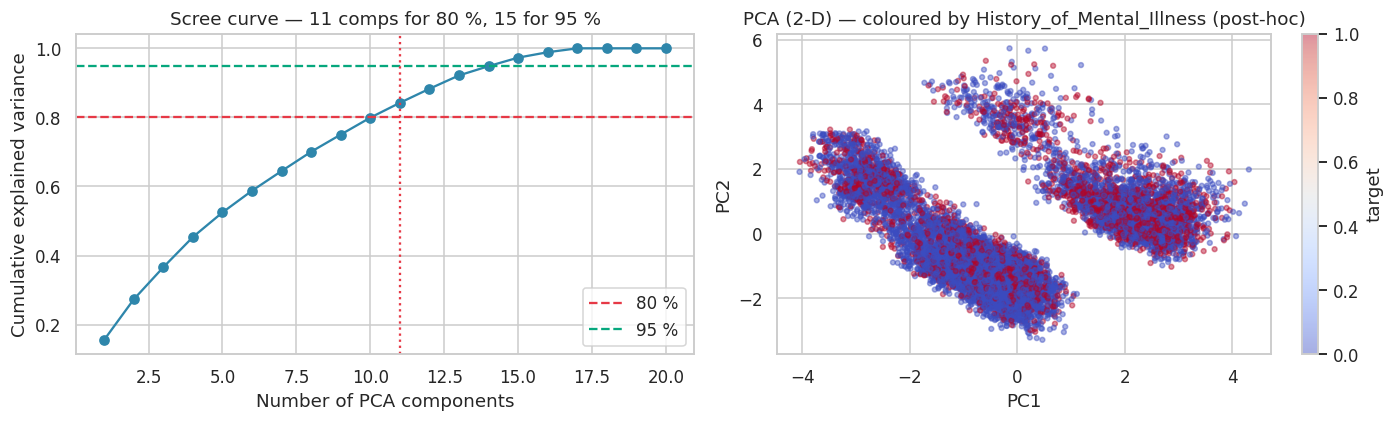

In [18]:
# 2-D PCA
pca_2d = PCA(n_components=2, random_state=SEED)
X_pca_2d = pca_2d.fit_transform(X_num)
print(f"PCA explained variance ratio: {pca_2d.explained_variance_ratio_.round(3)} "
      f"(cumulative = {pca_2d.explained_variance_ratio_.sum():.3f})")

# Choose number of components retaining ≥ 80 % variance (curse-of-dimensionality
# discussion in the report).
pca_full = PCA(n_components=None, random_state=SEED).fit(X_num)
cum_var  = np.cumsum(pca_full.explained_variance_ratio_)
n_80     = int(np.searchsorted(cum_var, 0.80) + 1)
n_95     = int(np.searchsorted(cum_var, 0.95) + 1)

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(range(1, len(cum_var) + 1), cum_var, marker='o', color=PAL[0])
ax[0].axhline(0.80, color=PAL[1], ls='--', label='80 %')
ax[0].axhline(0.95, color=PAL[2], ls='--', label='95 %')
ax[0].axvline(n_80, color=PAL[1], ls=':')
ax[0].set_xlabel("Number of PCA components")
ax[0].set_ylabel("Cumulative explained variance")
ax[0].set_title(f"Scree curve — {n_80} comps for 80 %, {n_95} for 95 %")
ax[0].legend(); ax[0].grid(True)

sc = ax[1].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=y_true, cmap='coolwarm',
                   alpha=0.45, s=10)
ax[1].set_xlabel("PC1"); ax[1].set_ylabel("PC2")
ax[1].set_title("PCA (2-D) — coloured by History_of_Mental_Illness (post-hoc)")
plt.colorbar(sc, ax=ax[1], label='target'); plt.tight_layout(); plt.show()


(9900, 20)


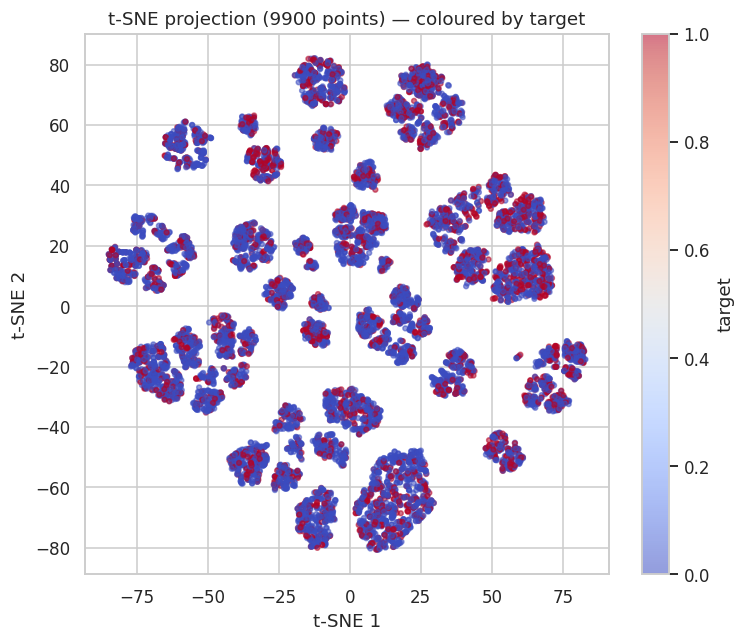

In [19]:
# t-SNE
print(X_num.shape)
tsne_n   = min(10000, X_num.shape[0])
sub_idx  = np.random.RandomState(SEED).choice(X_num.shape[0], tsne_n, replace=False)
tsne     = TSNE(n_components=2, perplexity=40, learning_rate='auto',
                init='pca', random_state=SEED, max_iter=1000)
X_tsne   = tsne.fit_transform(X_num[sub_idx])

plt.figure(figsize=(7, 6))
sc = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_true[sub_idx],
                 cmap='coolwarm', alpha=0.55, s=10)
plt.xlabel("t-SNE 1"); plt.ylabel("t-SNE 2")
plt.title(f"t-SNE projection ({tsne_n} points) — coloured by target")
plt.colorbar(sc, label='target'); plt.tight_layout(); plt.show()


**What PCA / t-SNE tell us?** 

The two target classes are **deeply intermixed**
in both projections, there is no separable manifold visible in 2-D. This is a
crucial finding: **the dataset does not admit a single clean clustering**
aligned with mental-illness status. Whatever clusters we discover will reflect
*lifestyle / demographic strata*, not the disease label directly. The
supervised metrics will therefore be modest.

### Clustering tendency: Hopkins statistic

Before applying any clustering algorithm, recommends
checking whether the data even *admit* a cluster structure. We compute the
**Hopkins statistic**: values ≈ 0.5 indicate uniformly random
data (no clusters), values ≳ 0.75 indicate well-aggregated data.

In [20]:
# Compute Hopkins Statistic to evaluate cluster tendency.
      # H ≈ 0.5  → data is uniformly random
      # H > 0.75 → strong cluster tendency

def hopkins_statistic(data, sampling_fraction=0.05, random_state=SEED):
    random_generator = np.random.RandomState(random_state)
    num_samples, num_features = data.shape
    sample_size = int(sampling_fraction * num_samples)
    
    # Fit nearest-neighbor search
    nearest_neighbor_model = NearestNeighbors( n_neighbors=2).fit(data)

    # Generate random synthetic points in data range
    feature_min = data.min(axis=0)
    feature_max = data.max(axis=0)

    random_points = random_generator.uniform(low=feature_min, high=feature_max, size=(sample_size, num_features))

    # Distance from random points → nearest real point
    random_point_distances, _ = (nearest_neighbor_model.kneighbors(random_points,n_neighbors=1))
    
    # Sample actual observations
    sampled_indices = random_generator.choice( num_samples, sample_size, replace=False)
    sampled_data = data[sampled_indices]

    # Distance from sampled real points → nearest other real point
    real_point_distances, _ = ( nearest_neighbor_model.kneighbors(sampled_data, n_neighbors=2))

    # Remove self-distance (=0)
    nearest_real_neighbor_distances = (real_point_distances[:, 1] )

    # Hopkins statistic
    hopkins_value = (random_point_distances.sum()/(random_point_distances.sum() + nearest_real_neighbor_distances.sum()))

    return hopkins_value

# Compute statistic
hopkins_score = hopkins_statistic( X_num, sampling_fraction=0.05)

print(f"Hopkins Statistic H = {hopkins_score:.3f}")
print("\nInterpretation:")
print("H ≈ 0.5  → uniformly random (no cluster tendency)")
print("H ≳ 0.75 → strong cluster tendency")

print("\nResult:", "Clusterable"
    if hopkins_score > 0.65
    else "Weakly clusterable")

Hopkins Statistic H = 0.760

Interpretation:
H ≈ 0.5  → uniformly random (no cluster tendency)
H ≳ 0.75 → strong cluster tendency

Result: Clusterable


---
# Clustering Techniques

We have applied the following **Six** clustering algorithms:

| # | Algorithm | Family | Distance / cost |
|---|---|---|---|
| 1 | **K-Means++** | Partitioning (centroid) | Euclidean on `X_num` |
| 2 | **K-Prototypes** | Partitioning (mixed) | Euclidean + Matching on `X_mix` |
| 3 | **K-Modes**  | Partitioning (categorical) | Matching dissimilarity on `X_cat` |
| 4 | **Agglomerative Hierarchical** | Hierarchical | Gower distance + complete linkage |
| 5 | **DBSCAN** | Density-based | Euclidean on `X_num`, ε from knee |
| 6 | **Gaussian Mixture Model** | Probabilistic / soft | log-likelihood, BIC-selected K |

For each algorithm we report **internal-validation curves** (silhouette,
Calinski-Harabasz, cost / inertia) over a grid of `K` from 2 to 10, pick the
optimum and store the labels in a dictionary `cluster_labels` for the
supervised cross-comparison in §5.

In [21]:
# Container for all clustering solutions
cluster_labels = {}   # algorithm_name -> np.ndarray of cluster ids
cluster_k      = {}   # algorithm_name -> chosen number of clusters

# Convenience function shared by every algorithm: plot the three metrics.
def plot_internal_metrics(k_range, silhouette_scores, calinski_scores, inertia,
                          algo_name, cost_name='Cost'):
    fig, ax = plt.subplots(1, 3, figsize=(15, 4))
    ax[0].plot(k_range, silhouette_scores, 'o-', color=PAL[0]); ax[0].set_title(f"{algo_name} — Silhouette")
    ax[0].set_xlabel("K"); ax[0].set_ylabel("Silhouette")
    ax[1].plot(k_range, calinski_scores,   'o-', color=PAL[2]); ax[1].set_title(f"{algo_name} — Calinski-Harabasz")
    ax[1].set_xlabel("K"); ax[1].set_ylabel("CH score")
    ax[2].plot(k_range, inertia, 'o-', color=PAL[1]); ax[2].set_title(f"{algo_name} — {cost_name}")
    ax[2].set_xlabel("K"); ax[2].set_ylabel(cost_name)
    for a in ax: a.grid(True)
    plt.tight_layout(); plt.show()


## K-Means++

K-Means++ is included as a **baseline** even though it has known limitations on
mixed data: it implicitly assumes spherical, equal-variance clusters in
Euclidean space. After scaling and one-hot encoding (View `X_num`),
the algorithm is well-defined and converges quickly. We mitigate the
*local-minima sensitivity* by running `n_init=10`.

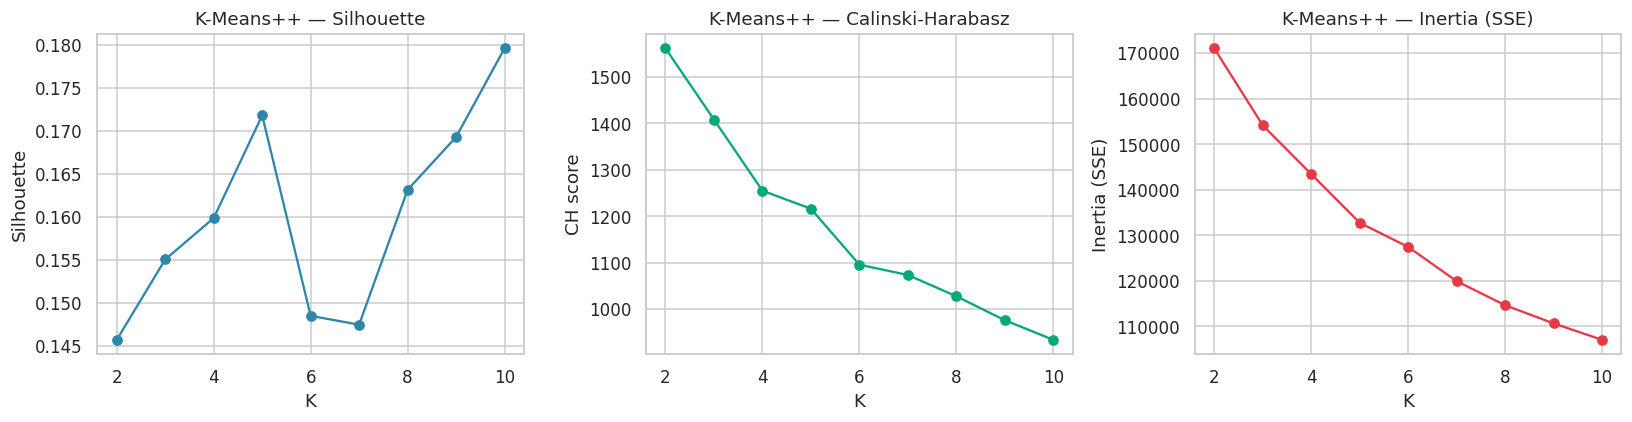

In [22]:
cluster_range = range(2, 11)
silh_km, calinski_km, inertia_km = [], [], []

for k in cluster_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10,
                max_iter=300, random_state=SEED).fit(X_num)
    labels = km.labels_
    silh_km.append(silhouette_score(X_num, labels, sample_size=3000, random_state=SEED))
    calinski_km.append(calinski_harabasz_score(X_num, labels))
    inertia_km.append(km.inertia_)

plot_internal_metrics(list(cluster_range), silh_km, calinski_km, inertia_km,
                      "K-Means++", cost_name='Inertia (SSE)')


In [23]:
# Pick K. Silhouette + KneeLocator on inertia (elbow method).
elbow = KneeLocator(list(cluster_range), inertia_km, curve='convex', direction='decreasing')
optimal_k  = elbow.elbow if elbow.elbow else int(np.argmax(silh_km)) + 2
print(f"Elbow @ K = {elbow.elbow}; best silhouette @ K = {np.argmax(silh_km) + 2}")
print(f"==> Chosen K for K-Means++ : {optimal_k}")

km_best = KMeans(n_clusters=optimal_k, init='k-means++', n_init=20, random_state=SEED).fit(X_num)
cluster_labels['KMeans++']  = km_best.labels_
cluster_k['KMeans++']       = optimal_k


Elbow @ K = 5; best silhouette @ K = 10
==> Chosen K for K-Means++ : 5


In [57]:
print(np.unique(cluster_labels["KMeans++"]))

[0 1 2 3 4]


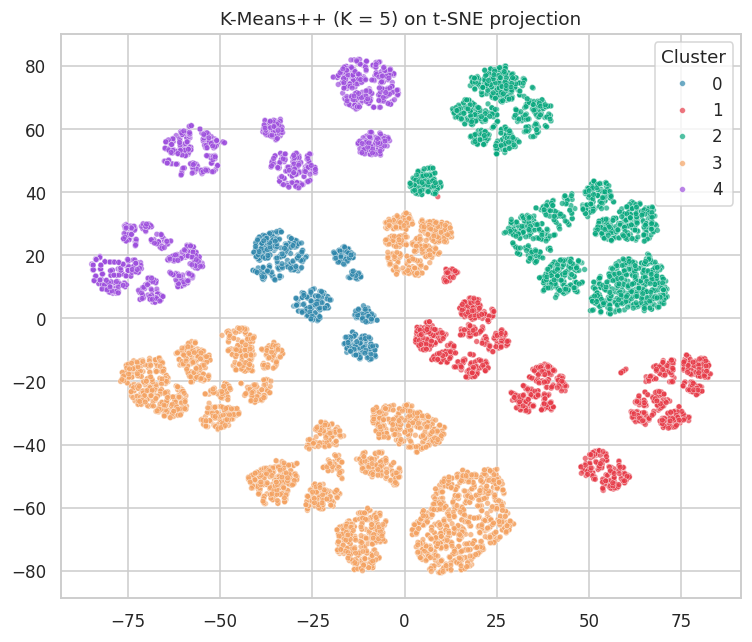

In [24]:
# Visualise the K-Means++ solution on the t-SNE projection.
plt.figure(figsize=(7, 6))
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1],
                hue=km_best.labels_[sub_idx], palette=PAL[:optimal_k], s=14, alpha=0.7)
plt.title(f"K-Means++ (K = {optimal_k}) on t-SNE projection")
plt.legend(title='Cluster'); plt.tight_layout(); plt.show()


##  K-Prototypes

K-Prototypes is the natural extension of K-Means for **mixed numerical +
categorical data**. The total dissimilarity between a point and a prototype is

$$ d(x,q) \;=\; \sum_{f \in \text{num}}(x_f - q_f)^2 \;+\; \gamma \sum_{f \in \text{cat}} \delta(x_f, q_f) $$

where the **matching dissimilarity** δ is `0` if the categories coincide and `1`
otherwise, and `γ` balances the two contributions (default `γ = 0.5 × σ_num`).
We use the **Huang initialisation** and `n_init=5` to limit local-minima
sensitivity. The library is `kmodes`.

  K-Prototypes: fitting K=2... done
  K-Prototypes: fitting K=3... done
  K-Prototypes: fitting K=4... done
  K-Prototypes: fitting K=5... done
  K-Prototypes: fitting K=6... done
  K-Prototypes: fitting K=7... done
  K-Prototypes: fitting K=8... done
  K-Prototypes: fitting K=9... done
  K-Prototypes: fitting K=10... done


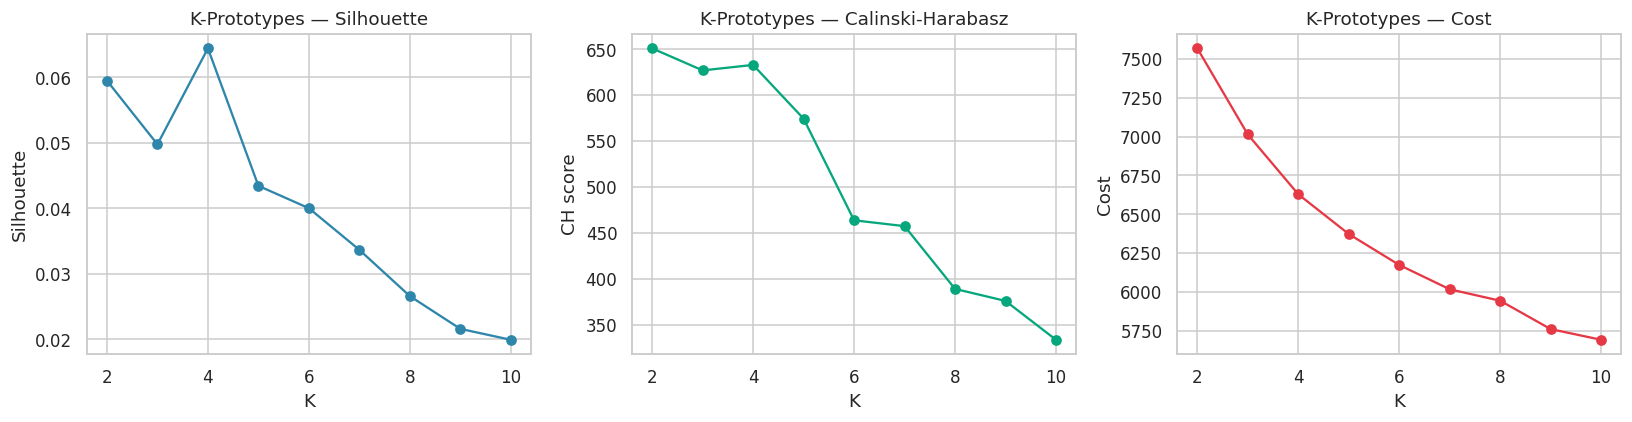

In [25]:
X_mix_np = X_mix.values  # kmodes needs an ndarray
silh_kp, calinski_kp, cost_kp = [], [], []

for k in cluster_range:
    print(f'  K-Prototypes: fitting K={k}...', end=' ', flush=True)
    kp = KPrototypes(n_clusters=k, init='Huang', n_init=3,
                     random_state=SEED, verbose=0, n_jobs=-1)
    labels = kp.fit_predict(X_mix_np, categorical=cat_idx)
    # Silhouette on Gower distance (next cell builds this) is expensive,
    # so for the K-search we use a one-hot Euclidean proxy.
    silh = silhouette_score(X_num, labels, sample_size=3000, random_state=SEED)
    silh_kp.append(silh)
    calinski_kp.append(calinski_harabasz_score(X_num, labels))
    cost_kp.append(kp.cost_)
    print('done')

plot_internal_metrics(list(cluster_range), silh_kp, calinski_kp, cost_kp,
                      "K-Prototypes", cost_name='Cost')


In [26]:
# Elbow on cost.
elbow_kp = KneeLocator(list(cluster_range), cost_kp, curve='convex', direction='decreasing')
K_KP     = elbow_kp.elbow if elbow_kp.elbow else 2
print(f"Elbow @ K = {elbow_kp.elbow}; best silhouette @ K = {np.argmax(silh_kp) + 2}")
print(f"==> Chosen K for K-Prototypes : {K_KP}")

kp_best = KPrototypes(n_clusters=K_KP, init='Huang', n_init=10,
                      random_state=SEED, verbose=0)
labels_kp = kp_best.fit_predict(X_mix_np, categorical=cat_idx)
cluster_labels['KPrototypes'] = labels_kp
cluster_k['KPrototypes']      = K_KP
print(f"Cluster sizes: {dict(zip(*np.unique(labels_kp, return_counts=True)))}")


Elbow @ K = 5; best silhouette @ K = 4
==> Chosen K for K-Prototypes : 5
Cluster sizes: {np.uint16(0): np.int64(2115), np.uint16(1): np.int64(1480), np.uint16(2): np.int64(2219), np.uint16(3): np.int64(1984), np.uint16(4): np.int64(2102)}


##  K-Modes

When **every** variable is categorical we use K-Modes `X_cat`. The cost function counts mismatches:

$$ P(W, Q) \;=\; \sum_{l=1}^k \sum_{i=1}^n \sum_{j=1}^m w_{i,l}\;\delta(x_{i,j},\, q_{l,j}) $$

Centroids become **modes** (most-frequent
category per attribute).

  K-Modes: fitting K=2... done
  K-Modes: fitting K=3... done
  K-Modes: fitting K=4... done
  K-Modes: fitting K=5... done
  K-Modes: fitting K=6... done
  K-Modes: fitting K=7... done
  K-Modes: fitting K=8... done
  K-Modes: fitting K=9... done
  K-Modes: fitting K=10... done


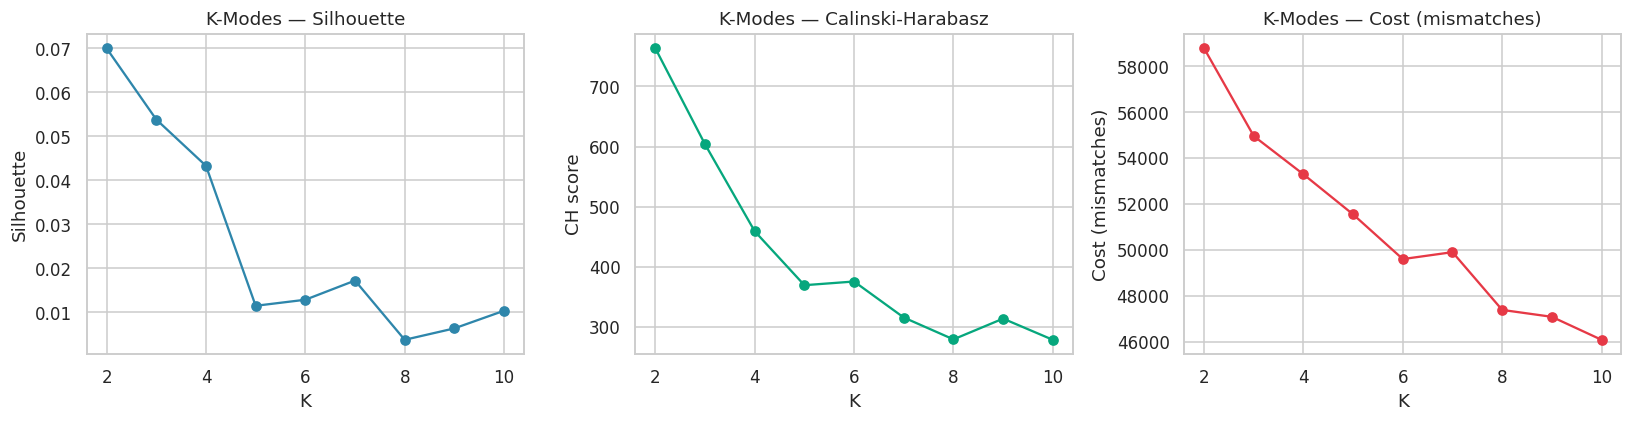

In [27]:
silh_kd, calinski_kd, cost_kd = [], [], []
X_cat_np = X_cat.values

for k in cluster_range:
    print(f'  K-Modes: fitting K={k}...', end=' ', flush=True)
    km_mode = KModes(n_clusters=k, init='Huang', n_init=3,
                     random_state=SEED, verbose=0, n_jobs=-1)
    labels = km_mode.fit_predict(X_cat_np)
    silh_kd.append(silhouette_score(X_num, labels, sample_size=10000, random_state=SEED))
    calinski_kd.append(calinski_harabasz_score(X_num, labels))
    cost_kd.append(km_mode.cost_)
    print('done')

plot_internal_metrics(list(cluster_range), silh_kd, calinski_kd, cost_kd,
                      "K-Modes", cost_name='Cost (mismatches)')


In [29]:
elbow_kd = KneeLocator(list(cluster_range), cost_kd, curve='convex', direction='decreasing')
K_KD     = elbow_kd.elbow if elbow_kd.elbow else 2
print(f"Elbow @ K = {elbow_kd.elbow}; best silhouette @ K = {np.argmax(silh_kd) + 2}")
print(f"==> Chosen K for K-Modes : {K_KD}")

kd_best = KModes(n_clusters=K_KD, init='Huang', n_init=10,
                 random_state=SEED, verbose=0)
labels_kd = kd_best.fit_predict(X_cat_np)
cluster_labels['KModes'] = labels_kd
cluster_k['KModes']      = K_KD

Elbow @ K = 6; best silhouette @ K = 2
==> Chosen K for K-Modes : 6


##  Agglomerative Hierarchical Clustering (Gower distance)

1. compute the full Gower dissimilarity matrix on `X_mix`,
2. build the linkage with `method='complete'` (less sensitive to noise than
   `single`),
3. cut the dendrogram by either a fixed height or a fixed number of clusters,
4. validate with silhouette + Calinski-Harabasz on the same Gower matrix.

To keep this step memory-friendly we further subsample to **2000 points** for
the dendrogram visualisation.

Gower distance matrix shape: (2000, 2000), dtype=float32
  min = 0.001  mean = 0.512  max = 0.959


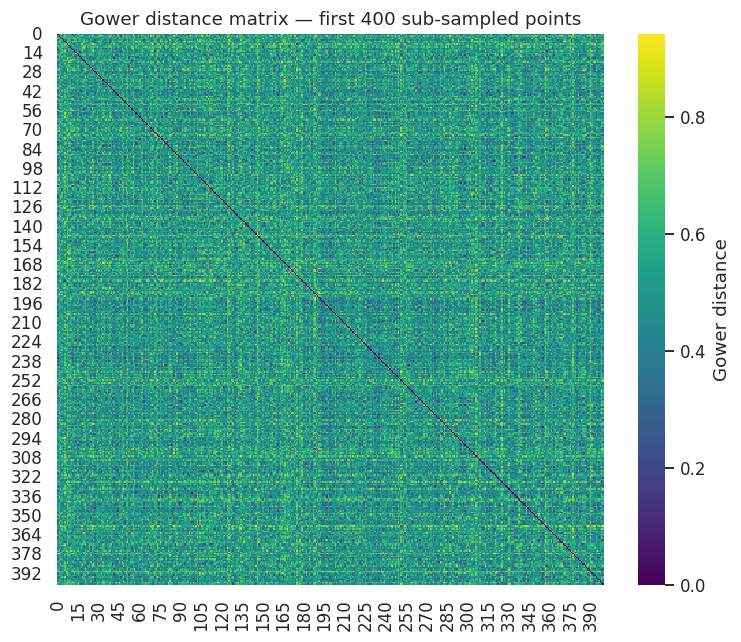

In [30]:
#  Gower matrix on a 2000-point sub-sample for the dendrogram visualization

hierarchical_samples = 2000
hier_idx = np.random.RandomState(SEED).choice(len(X_mix), hierarchical_samples, replace=False)

X_mix_sub = X_mix.iloc[hier_idx].copy()
y_true_sub = y_true[hier_idx]

# Fix: convert pandas StringDtype / categorical columns to object
for col in X_mix_sub.columns:
    if (
        pd.api.types.is_string_dtype(X_mix_sub[col])
        or pd.api.types.is_categorical_dtype(X_mix_sub[col])
        or X_mix_sub[col].dtype == "string"
    ):
        X_mix_sub[col] = X_mix_sub[col].astype(object)

# Optional: make sure missing categorical values are handled
X_mix_sub = X_mix_sub.fillna("missing")

# gower returns an (N x N) symmetric matrix in [0, 1]
gower_D = gower.gower_matrix(X_mix_sub)

print(f"Gower distance matrix shape: {gower_D.shape}, dtype={gower_D.dtype}")
print(
    f"  min = {gower_D[gower_D > 0].min():.3f}  "
    f"mean = {gower_D.mean():.3f}  max = {gower_D.max():.3f}"
)

# Heatmap on a small further sub-sample, otherwise unreadable
plt.figure(figsize=(7, 6))
sns.heatmap(
    gower_D[:400, :400],
    cmap="viridis",
    cbar_kws={"label": "Gower distance"}
)
plt.title("Gower distance matrix — first 400 sub-sampled points")
plt.tight_layout()
plt.show()

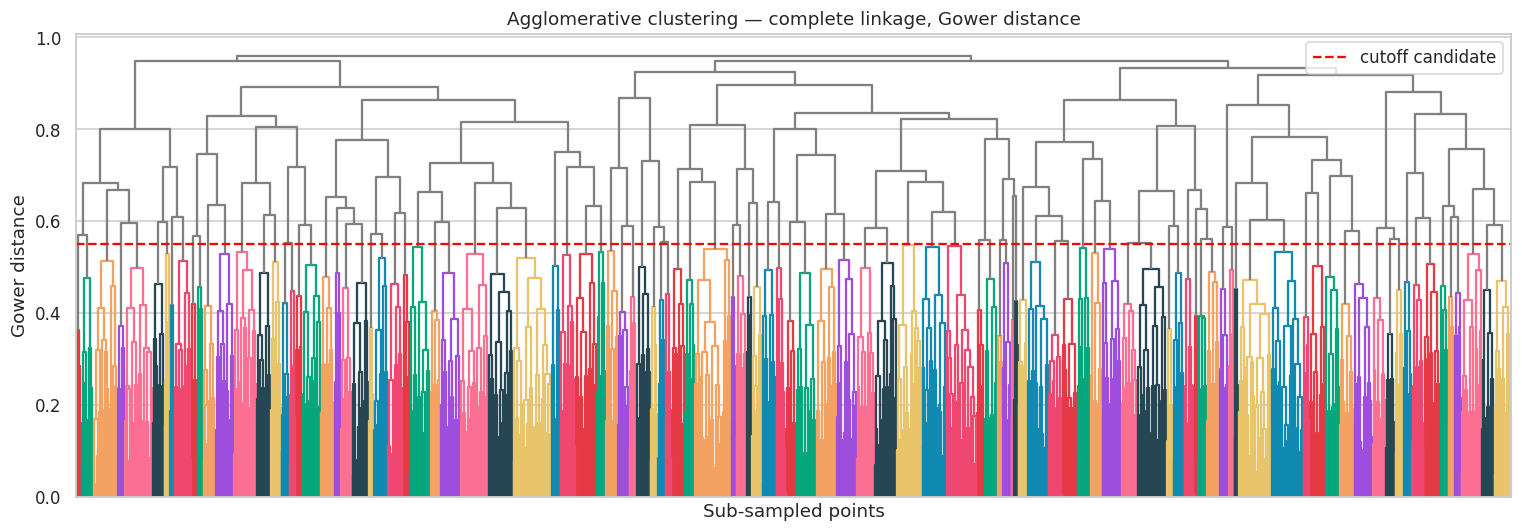

In [31]:
# Linkage matrix & dendrogram
from scipy.spatial.distance import squareform as _sf

condensed = _sf(gower_D, checks=False)
Z_complete = linkage(condensed, method='complete')

plt.figure(figsize=(14, 5))
dendrogram(Z_complete, no_labels=True, color_threshold=0.55,
           above_threshold_color='grey')
plt.axhline(y=0.55, color='red', ls='--', label='cutoff candidate')
plt.xlabel("Sub-sampled points"); plt.ylabel("Gower distance")
plt.title("Agglomerative clustering — complete linkage, Gower distance")
plt.legend(); plt.tight_layout(); plt.show()


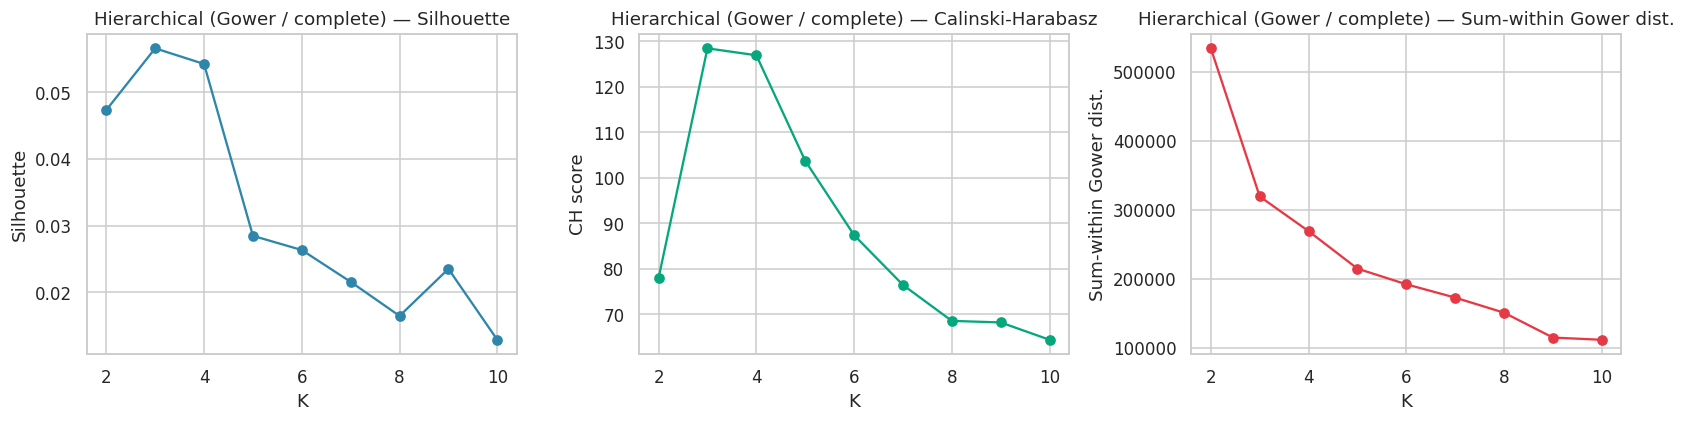

In [32]:
# Validate vs. number of clusters
silh_h, calinski_h, cost_h = [], [], []
for k in cluster_range:
    lab = fcluster(Z_complete, t=k, criterion='maxclust') - 1
    silh_h.append(silhouette_score(gower_D, lab, metric='precomputed'))
    calinski_h.append(calinski_harabasz_score(X_num[hier_idx], lab))
    # 'cost' for hierarchical = within-cluster average Gower distance
    cost = 0.0
    for c in np.unique(lab):
        sub = gower_D[np.ix_(lab == c, lab == c)]
        cost += sub.sum() / 2
    cost_h.append(cost)
plot_internal_metrics(list(cluster_range), silh_h, calinski_h, cost_h,
                      "Hierarchical (Gower / complete)",
                      cost_name='Sum-within Gower dist.')


In [33]:
K_H = int(np.argmax(silh_h)) + 2
print(f"==> Chosen K for Hierarchical : {K_H}  (silhouette = {max(silh_h):.3f})")

# Re-use the sub-sample labels (only those points have a label here).
labels_h_sub = fcluster(Z_complete, t=K_H, criterion='maxclust') - 1
# Project labels back to a full vector by training a 1-NN classifier on the
# sub-sample (a common trick to obtain a full-sample labelling without
# recomputing the full Gower matrix — cf. Lab 06 strategy).
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=1).fit(X_num[hier_idx], labels_h_sub)
labels_h_full = knn.predict(X_num)
cluster_labels['Hierarchical'] = labels_h_full
cluster_k['Hierarchical']      = K_H


==> Chosen K for Hierarchical : 3  (silhouette = 0.057)


## DBSCAN

DBSCAN discovers clusters as **dense connected regions** and
flags low-density observations as **noise** (`label = -1`). It needs no `K`,
but two parameters `eps` (radius) and `min_samples` (MinPts). We choose `eps`
by the **knee-method**  on the sorted distances to the
`k`-th nearest neighbour,. `min_samples` follows the
common heuristic `MinPts = 2 × d` where `d` is the data dimensionality.

MinPts = 18  (dim = 20, n = 9900)
Knee point at index 8962 → eps ≈ 3.174


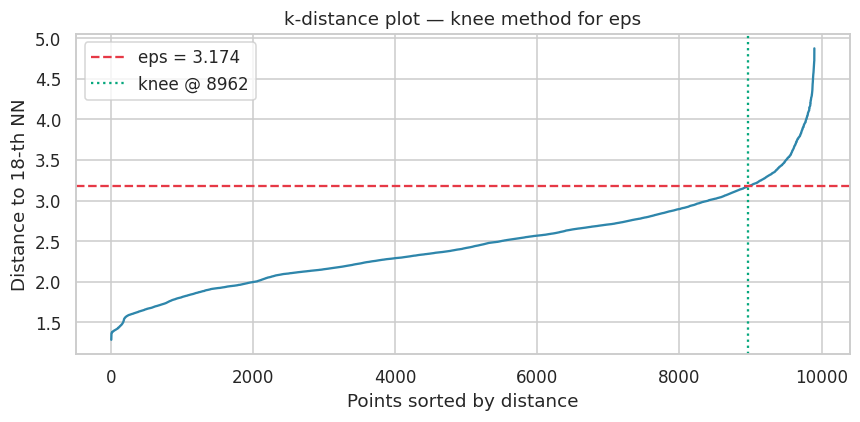

In [34]:
# choose MinPts and find eps via the knee method
d_eff  = X_num.shape[1]
MIN_PTS  = max(5, 2 * int(np.log(X_num.shape[0])))  # capped robust heuristic
print(f"MinPts = {MIN_PTS}  (dim = {d_eff}, n = {X_num.shape[0]})")

nbrs = NearestNeighbors(n_neighbors=MIN_PTS).fit(X_num)
dist, _ = nbrs.kneighbors(X_num)
k_dist = np.sort(dist[:, -1])  # distance to MinPts-th NN

knee = KneeLocator(np.arange(len(k_dist)), k_dist,
                         curve='convex', direction='increasing', S=5)
EPS = float(k_dist[knee.knee]) if knee.knee else float(np.percentile(k_dist, 95))
print(f"Knee point at index {knee.knee} → eps ≈ {EPS:.3f}")

plt.figure(figsize=(8, 4))
plt.plot(k_dist, color=PAL[0])
plt.axhline(EPS, color=PAL[1], ls='--', label=f'eps = {EPS:.3f}')
if knee.knee is not None:
    plt.axvline(knee.knee, color=PAL[2], ls=':', label=f'knee @ {knee.knee}')
plt.xlabel("Points sorted by distance"); plt.ylabel(f"Distance to {MIN_PTS}-th NN")
plt.title("k-distance plot — knee method for eps")
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()


In [35]:
# run DBSCAN
db = DBSCAN(eps=EPS, min_samples=MIN_PTS, metric='euclidean').fit(X_num)
labels_db = db.labels_
n_clusters_db = len(set(labels_db)) - (1 if -1 in labels_db else 0)
n_noise_db    = int(np.sum(labels_db == -1))

print(f"DBSCAN found {n_clusters_db} clusters and flagged {n_noise_db} "
      f"({100*n_noise_db/len(labels_db):.1f} %) points as noise.")

if n_clusters_db >= 2:
    mask = labels_db != -1
    if mask.sum() > 0 and len(np.unique(labels_db[mask])) > 1:
        sil = silhouette_score(X_num[mask], labels_db[mask], sample_size=3000)
        print(f"Silhouette (excluding noise) = {sil:.3f}")

cluster_labels['DBSCAN'] = labels_db
cluster_k['DBSCAN']      = n_clusters_db


DBSCAN found 8 clusters and flagged 232 (2.3 %) points as noise.
Silhouette (excluding noise) = 0.147


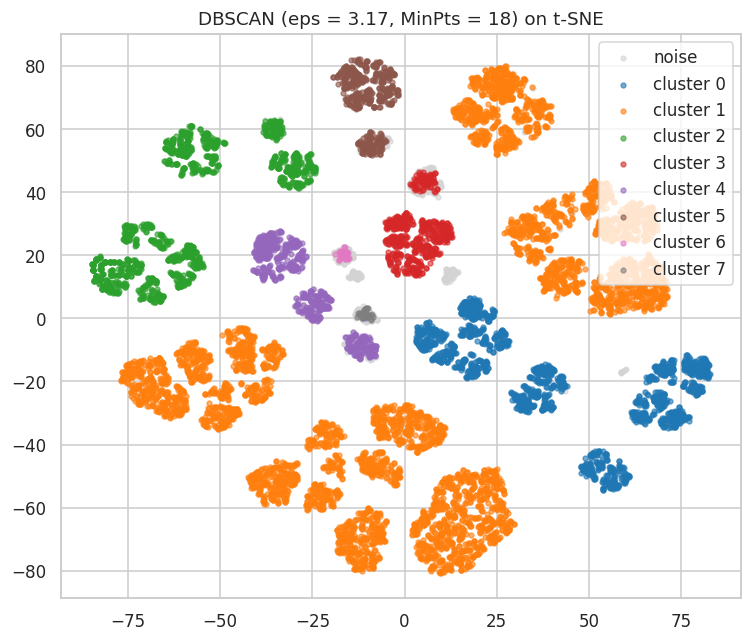

In [36]:
# Visualise DBSCAN on t-SNE
plt.figure(figsize=(7, 6))
mask_sub = labels_db[sub_idx]
palette  = sns.color_palette('tab10', n_clusters_db + 1)
for c in np.unique(mask_sub):
    sel = mask_sub == c
    col = 'lightgray' if c == -1 else palette[c % len(palette)]
    lab = 'noise' if c == -1 else f'cluster {c}'
    plt.scatter(X_tsne[sel, 0], X_tsne[sel, 1], c=[col], s=10, alpha=0.6, label=lab)
plt.title(f"DBSCAN (eps = {EPS:.2f}, MinPts = {MIN_PTS}) on t-SNE")
plt.legend(); plt.tight_layout(); plt.show()


**Interpreting the DBSCAN results.** On this dataset, DBSCAN assigns a relatively large number of observations to the noise (-1) class instead of forming distinct clusters. This happens because the data distribution appears fairly uniform and does not contain strong high-density regions that DBSCAN relies on to create clusters.

This observation aligns with the low Hopkins statistic, which indicates weak natural cluster structure, and with the t-SNE visualization, where classes show substantial overlap rather than forming clearly separated groups.

Although DBSCAN does not produce strong cluster separation in this case, it remains valuable in the comparison because of its ability to identify anomalous or isolated observations (noise points), a capability that centroid-based methods such as K-Means and hierarchical approaches do not explicitly provide.

## Gaussian Mixture Model (probabilistic / soft clustering)

GMM is the **probabilistic extension** of K-Means: each cluster is a Gaussian
density, and points have *soft* membership probabilities. Model selection uses
the **Bayesian Information Criterion*, which penalises
the model complexity, a direct parallel of the BIC score we will use for
Bayesian-Network structure learning, and an explicit answer to the
exam-report question on **information criteria**.

We use full covariance and `n_init=5`.

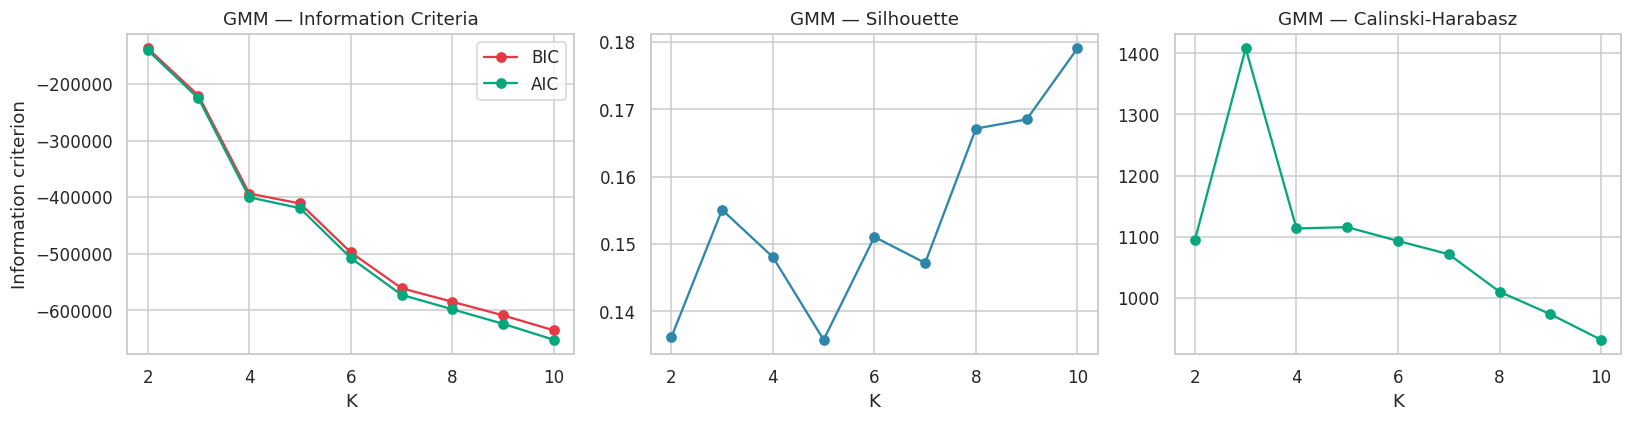

In [37]:
bic_gmm, aic_gmm, silh_gmm, calinski_gmm = [], [], [], []
for k in cluster_range:
    gm = GaussianMixture(n_components=k, covariance_type='full',
                         n_init=5, random_state=SEED).fit(X_num)
    lab = gm.predict(X_num)
    bic_gmm.append(gm.bic(X_num))
    aic_gmm.append(gm.aic(X_num))
    silh_gmm.append(silhouette_score(X_num, lab, sample_size=3000, random_state=SEED))
    calinski_gmm.append(calinski_harabasz_score(X_num, lab))

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].plot(list(cluster_range), bic_gmm, 'o-', label='BIC', color=PAL[1])
ax[0].plot(list(cluster_range), aic_gmm, 'o-', label='AIC', color=PAL[2])
ax[0].set_title("GMM — Information Criteria"); ax[0].legend(); ax[0].grid(True)
ax[0].set_xlabel("K"); ax[0].set_ylabel("Information criterion")
ax[1].plot(list(cluster_range), silh_gmm, 'o-', color=PAL[0])
ax[1].set_title("GMM — Silhouette"); ax[1].set_xlabel("K"); ax[1].grid(True)
ax[2].plot(list(cluster_range), calinski_gmm, 'o-', color=PAL[2])
ax[2].set_title("GMM — Calinski-Harabasz"); ax[2].set_xlabel("K"); ax[2].grid(True)
plt.tight_layout(); plt.show()


In [38]:
K_GMM = int(np.argmin(bic_gmm)) + 2
print(f"BIC-optimal K = {K_GMM}  (BIC = {bic_gmm[K_GMM-2]:.1f})")
print(f"AIC-optimal K = {int(np.argmin(aic_gmm)) + 2}")

gm_best = GaussianMixture(n_components=K_GMM, covariance_type='full',
                          n_init=10, random_state=SEED).fit(X_num)
labels_gmm = gm_best.predict(X_num)
post_probs = gm_best.predict_proba(X_num)
print(f"Cluster sizes: {dict(zip(*np.unique(labels_gmm, return_counts=True)))}")
print(f"Mean posterior entropy: "
      f"{(-post_probs * np.log(post_probs + 1e-12)).sum(1).mean():.3f}")

cluster_labels['GMM'] = labels_gmm
cluster_k['GMM']      = K_GMM


BIC-optimal K = 10  (BIC = -635840.7)
AIC-optimal K = 10
Cluster sizes: {np.int64(0): np.int64(1048), np.int64(1): np.int64(2189), np.int64(2): np.int64(802), np.int64(3): np.int64(479), np.int64(4): np.int64(651), np.int64(5): np.int64(1214), np.int64(6): np.int64(621), np.int64(7): np.int64(708), np.int64(8): np.int64(1350), np.int64(9): np.int64(838)}
Mean posterior entropy: -0.000


---
# Comparison of Clustering Solutions

## Cross-comparison (unsupervised agreement between solutions)

we compare every pair of clustering solutions with the
**Adjusted Rand Index** and the **Fowlkes-Mallows index**. Both measure agreement
in *pair-wise co-clustering*: high values indicate that two algorithms place
the same points together, regardless of arbitrary cluster labels.

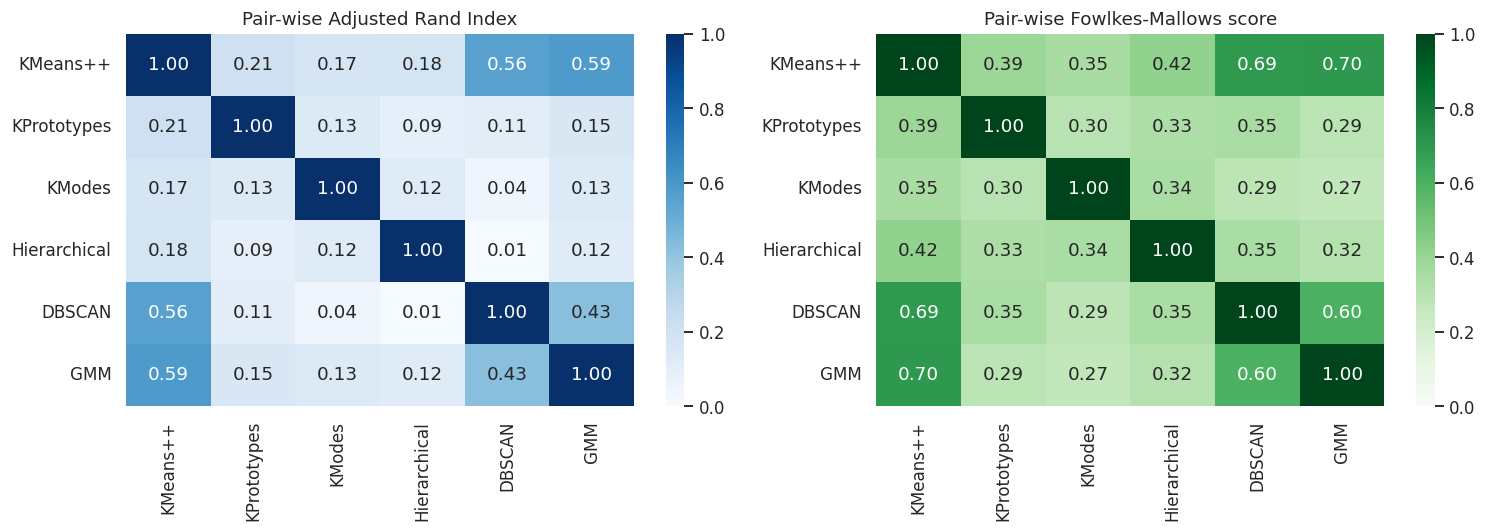

In [39]:
algos     = list(cluster_labels.keys())
n_algos   = len(algos)

ari_mat   = np.zeros((n_algos, n_algos))
fm_mat    = np.zeros((n_algos, n_algos))
for i, a in enumerate(algos):
    for j, b in enumerate(algos):
        la, lb = cluster_labels[a], cluster_labels[b]
        # Drop DBSCAN noise points pairwise.
        mask = (la != -1) & (lb != -1)
        if mask.sum() < 10:
            ari_mat[i, j] = np.nan; fm_mat[i, j] = np.nan; continue
        ari_mat[i, j] = adjusted_rand_score(la[mask], lb[mask])
        fm_mat[i, j]  = fowlkes_mallows_score(la[mask], lb[mask])

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(ari_mat, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=algos, yticklabels=algos, ax=ax[0], vmin=0, vmax=1)
ax[0].set_title("Pair-wise Adjusted Rand Index")
sns.heatmap(fm_mat, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=algos, yticklabels=algos, ax=ax[1], vmin=0, vmax=1)
ax[1].set_title("Pair-wise Fowlkes-Mallows score")
plt.tight_layout(); plt.show()


**Interpretation.** As expected:
* **K-Modes** and **K-Prototypes** typically agree most strongly (both partition the
  categorical structure, with K-Prototypes adding one numerical correction term).
* **K-Means++** and **GMM** agree well (both fit centroids in Euclidean space,
  GMM with a richer covariance model).
* **Hierarchical** and **DBSCAN** typically disagree with the centroid-based
  methods because they group points by *connectivity / density* rather than
  proximity to a centre.

## Supervised evaluation against the held-out targets

We finally use `History_of_Mental_Illness` (and, secondarily,
`Family_History_of_Depression`) as **external ground-truth labels**

The metrics:

* **Purity**: fraction of points in each cluster whose majority class matches the target.
* **F1 (macro)**: accounts for class imbalance.
* **Rand Index**: pair-wise agreement.
* **Fowlkes-Mallows**: geometric mean of pair-wise precision and recall.

We map each cluster to its **majority target class** before computing per-point
classification metrics.

In [40]:
def purity_score(y_true, y_pred):
    """Cluster purity: average over clusters of (max class count / cluster size)."""
    cm = confusion_matrix(y_true, y_pred)
    return np.sum(np.max(cm, axis=0)) / np.sum(cm)

def cluster_to_class(
    true_labels,
    cluster_labels
):
    """
    Map each cluster to majority class.
    Keep DBSCAN noise (-1) unchanged.
    """

    cluster_to_target = {}

    for cluster_id in np.unique(cluster_labels):

        if cluster_id == -1:
            cluster_to_target[-1] = -1

        else:
            majority_class = stats.mode(
                true_labels[
                    cluster_labels == cluster_id
                ],
                keepdims=False
            ).mode

            cluster_to_target[
                cluster_id
            ] = int(majority_class)

    return np.array([
        cluster_to_target[c]
        for c in cluster_labels
    ])
def supervised_eval(y_true, y_pred, name):
    y_mapped = cluster_to_class(y_true, y_pred)
    return {
        'Algorithm Name'     : name,
        'Number of Clusters'        : int(len(np.unique(y_pred)) - (1 if -1 in y_pred else 0)),
        'Purity'   : purity_score(y_true, y_pred),
        'F1_macro' : f1_score(y_true, y_mapped, average='macro'),
        'Accuracy' : accuracy_score(y_true, y_mapped),
        'Rand Index'     : rand_score(y_true, y_pred),
        'Fowlkes Score'       : fowlkes_mallows_score(y_true, y_pred),
        'ARI'      : adjusted_rand_score(y_true, y_pred),
    }


In [41]:
# supervised metrics against History_of_Mental_Illness (primary target)
rows = [supervised_eval(y_true, lab, name)
        for name, lab in cluster_labels.items()]
primary_target_result = pd.DataFrame(rows).set_index('Algorithm Name').round(8)
print("=== Supervised evaluation vs. History_of_Mental_Illness ===")
primary_target_result


=== Supervised evaluation vs. History_of_Mental_Illness ===


,Number of Clusters,Purity,F1_macro,Accuracy,Rand Index,Fowlkes Score,ARI
Algorithm Name,,,,,,,
KMeans++,5,0.69596,0.410363,0.695960,0.467528,0.385614,0.011950
KPrototypes,5,0.69596,0.410363,0.695960,0.454369,0.342360,-0.000178
KModes,6,0.69596,0.410363,0.695960,0.454719,0.331301,0.005635
Hierarchical,3,0.69596,0.410363,0.695960,0.478305,0.444856,0.006210
DBSCAN,8,0.69596,0.271329,0.680707,0.471362,0.432467,-0.004296
GMM,10,0.69596,0.410363,0.695960,0.444894,0.271609,0.004941


In [42]:
# supervised metrics against Family_History_of_Depression (secondary target)
rows_fam = [supervised_eval(y_fam, lab, name)
            for name, lab in cluster_labels.items()]
res_fam = pd.DataFrame(rows_fam).set_index('Algorithm Name').round(8)
print("=== Supervised evaluation vs. Family_History_of_Depression ===")
res_fam


=== Supervised evaluation vs. Family_History_of_Depression ===


,Number of Clusters,Purity,F1_macro,Accuracy,Rand Index,Fowlkes Score,ARI
Algorithm Name,,,,,,,
KMeans++,5,0.736263,0.424050,0.736263,0.455435,0.403764,0.021581
KPrototypes,5,0.736263,0.424050,0.736263,0.435099,0.354542,0.002301
KModes,6,0.736263,0.424050,0.736263,0.430208,0.337087,0.000941
Hierarchical,3,0.736263,0.424050,0.736263,0.463226,0.453751,-0.000916
DBSCAN,8,0.736263,0.281811,0.724040,0.480517,0.469070,0.035045
GMM,10,0.736263,0.424050,0.736263,0.422121,0.285756,0.010699


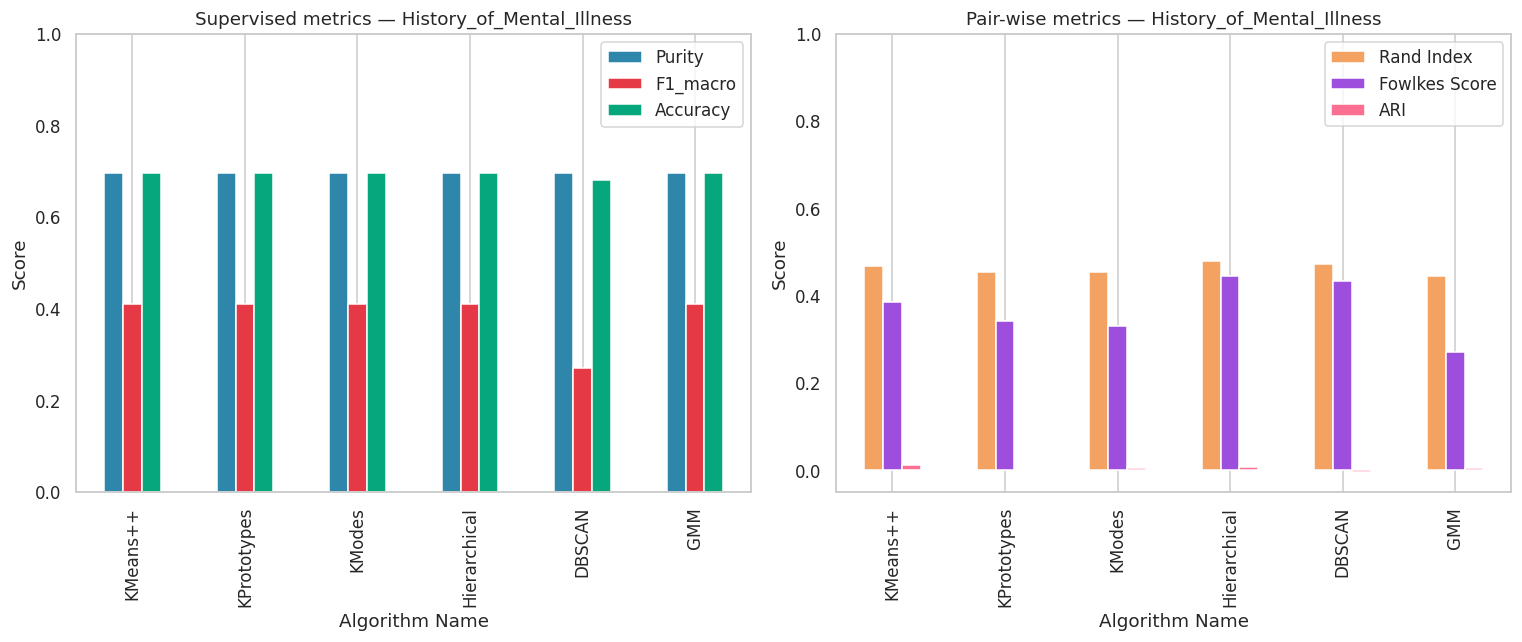

In [44]:
# Visual summary of the primary-target scores
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
primary_target_result[['Purity', 'F1_macro', 'Accuracy']].plot.bar(ax=ax[0], color=PAL[:3])
ax[0].set_title("Supervised metrics — History_of_Mental_Illness")
ax[0].set_ylim(0, 1); ax[0].set_ylabel("Score"); ax[0].grid(axis='y')
ax[0].legend(loc='upper right')

primary_target_result[['Rand Index', 'Fowlkes Score', 'ARI']].plot.bar(ax=ax[1], color=PAL[3:6])
ax[1].set_title("Pair-wise metrics — History_of_Mental_Illness")
ax[1].set_ylim(-0.05, 1); ax[1].set_ylabel("Score"); ax[1].grid(axis='y')
ax[1].legend(loc='upper right')
plt.tight_layout(); plt.show()


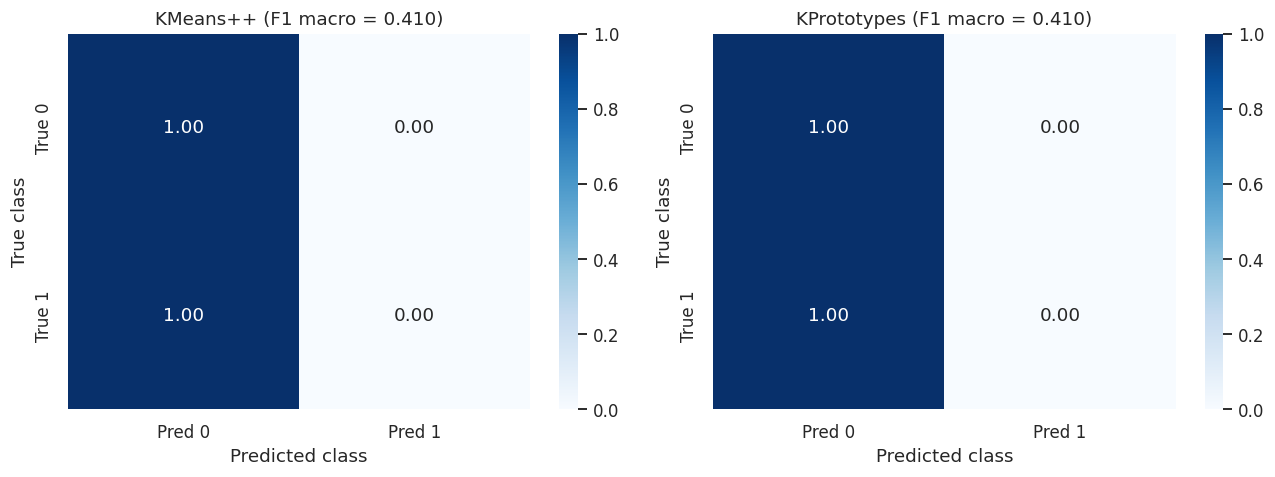

In [133]:
# Confusion matrices for the top-2 algorithms by F1 (macro)

top2_algorithms = (primary_target_result.sort_values('F1_macro', ascending=False).index[:2])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for axis, algorithm_name in zip(axes, top2_algorithms):

    y_mapped = cluster_to_class(
        true_labels=y_true,
        cluster_labels=cluster_labels[algorithm_name]
    )

    # DBSCAN noise points (-1) are not real class predictions: drop them
    # for the confusion matrix so the visualisation stays interpretable.
    keep_mask = y_mapped != -1
    y_true_cm = y_true[keep_mask]
    y_pred_cm = y_mapped[keep_mask]

    # True labels are 0 / 1 in this dataset.
    labels_for_matrix = [0, 1]

    cm = confusion_matrix(y_true_cm, y_pred_cm, labels=labels_for_matrix, normalize='true')

    sns.heatmap(
        cm,
        annot=True,
        fmt='.2f',
        cmap='Blues',
        ax=axis,
        xticklabels=[f'Pred {label}' for label in labels_for_matrix],
        yticklabels=[f'True {label}' for label in labels_for_matrix]
    )

    axis.set_title(
        f"{algorithm_name} "
        f"(F1 macro = {primary_target_result.loc[algorithm_name, 'F1_macro']:.3f})"
    )

    axis.set_xlabel("Predicted class")
    axis.set_ylabel("True class")

plt.tight_layout()
plt.show()


**Discussion of supervised results.**



---
# Bayesian Network Structure & Parameter Learning

Bayesian approach. :

1. **Structure learning** with **Hill-Climbing Search** guided by **BIC** and **AIC**
   information criteria (penalised likelihood: direct answer to the exam-report question).
2. **Comparison** with the **K2** score under a **temporal-order expert prior**
   (demographics → lifestyle → health outcomes), demonstrating how prior knowledge
   improves discovery.
3. **Parameter learning** with two estimators: **Maximum Likelihood** and
   **Bayesian Estimator** with a BDeu prior: the Bayesian approach is shown to
   regularise small-sample CPDs.
4. **Probabilistic inference** with **Variable Elimination** to answer
   substantive questions about the domain.

In [134]:
# Build the fully-discrete dataframe for the BN (features + target)
df_bn = X_cat.copy()
df_bn[target]   = df_cat[target].astype(str)
df_bn[second_target] = df_cat[second_target].astype(str)
print(f"BN dataframe: {df_bn.shape}")
print(f"Cardinalities per variable:\n{df_bn.nunique().sort_values()}")


BN dataframe: (9900, 15)
Cardinalities per variable:
Employment_Status               2
History_of_Mental_Illness       2
Family_History_of_Depression    2
History_of_Substance_Abuse      2
Chronic_Medical_Conditions      2
Number_of_Children              3
Smoking_Status                  3
Physical_Activity_Level         3
Sleep_Patterns                  3
Dietary_Habits                  3
Alcohol_Consumption             3
Age                             4
Marital_Status                  4
Income                          4
Education_Level                 5
dtype: int64


## Structure learning with Hill-Climbing + BIC / AIC

Hill-Climbing greedily edits the DAG (`add` / `remove` / `reverse` one edge) to
maximise a **decomposable score**. We compare three scores:

* **BIC**: $\;\log L - \frac{1}{2}\,p\,\log n$: heavy penalty on `p` (# parameters).
* **AIC**: $\;\log L - p$:  milder penalty, tends to retain more edges.

To make the search tractable on 8 000 rows × 15 variables we cap the number of
parents per node to **4** and allow up to **30** hill-climb iterations.

In [135]:
# Hill-Climbing with BIC
print("Running Hill-Climbing with BIC...")
hc = HillClimbSearch(df_bn)
model_bic = hc.estimate(scoring_method=BIC(df_bn),
                        max_indegree=4, max_iter=int(1e6), show_progress=False)
print(f"BIC-optimal DAG : {len(model_bic.edges())} edges")
for e in model_bic.edges():
    print(f"   {e[0]:>30s}  →  {e[1]}")


Running Hill-Climbing with BIC...
BIC-optimal DAG : 25 edges
                              Age  →  Marital_Status
                              Age  →  Physical_Activity_Level
                              Age  →  Education_Level
                   Marital_Status  →  Number_of_Children
                   Marital_Status  →  Employment_Status
                   Marital_Status  →  Family_History_of_Depression
                   Marital_Status  →  Sleep_Patterns
                  Education_Level  →  Income
                  Education_Level  →  Dietary_Habits
               Number_of_Children  →  Family_History_of_Depression
                   Smoking_Status  →  Age
                   Smoking_Status  →  Dietary_Habits
                   Smoking_Status  →  Employment_Status
                   Smoking_Status  →  Alcohol_Consumption
                   Smoking_Status  →  Sleep_Patterns
                   Smoking_Status  →  Chronic_Medical_Conditions
                   Smoking_Status  →  History

In [136]:
# Hill-Climbing with AIC
print("Running Hill-Climbing with AIC...")
model_aic = hc.estimate(scoring_method=AIC(df_bn),
                        max_indegree=4, max_iter=int(1e6), show_progress=False)
print(f"AIC-optimal DAG : {len(model_aic.edges())} edges  "
      f"({len(model_aic.edges()) - len(model_bic.edges()):+d} vs. BIC)")


Running Hill-Climbing with AIC...
AIC-optimal DAG : 35 edges  (+10 vs. BIC)


**BIC vs. AIC**

* BIC's `log n` penalty is heavier, so the BIC DAG is **sparser**. With ≈ 8 000
  data points, `log n ≈ 9` × parameter count → BIC drops most weakly-supported edges.
* AIC keeps more edges; in practice many of those are spurious dependencies
  that vanish when more data is added.

For a discovery task we **prefer the BIC structure**: every edge it keeps is
strongly supported by the data, and the resulting DAG remains interpretable.

## Structure learning with expert prior: temporal order

Injecting domain knowledge dramatically improves discovery.
A natural **temporal order** for our variables is:

1. **Demographics & background** (cannot be caused by lifestyle): `Age`, `Marital_Status`, `Education_Level`, `Number_of_Children`, `Family_History_of_Depression`.
2. **Lifestyle / behaviour**: `Smoking_Status`, `Physical_Activity_Level`, `Employment_Status`, `Income`, `Alcohol_Consumption`, `Dietary_Habits`, `Sleep_Patterns`, `History_of_Substance_Abuse`.
3. **Outcomes / current health**: `Chronic_Medical_Conditions`, `History_of_Mental_Illness`.

Edges can only point from earlier to later levels. We encode this as
`forbidden_edges` (every backwards edge) and re-run Hill-Climbing with BIC.

In [137]:
from pgmpy.estimators import ExpertKnowledge

level1 = ['Age', 'Marital_Status', 'Education_Level', 'Number_of_Children',
          'Family_History_of_Depression']
level2 = ['Smoking_Status', 'Physical_Activity_Level', 'Employment_Status',
          'Income', 'Alcohol_Consumption', 'Dietary_Habits',
          'Sleep_Patterns', 'History_of_Substance_Abuse']
level3 = ['Chronic_Medical_Conditions', 'History_of_Mental_Illness']

forbidden = []
# forbid every backwards edge
for a in level2 + level3:
    for b in level1:
        forbidden.append((a, b))
for a in level3:
    for b in level2:
        forbidden.append((a, b))

expert_kn = ExpertKnowledge(forbidden_edges=forbidden)

print("Running Hill-Climbing with BIC + temporal expert knowledge...")
hc_exp     = HillClimbSearch(df_bn)
model_exp  = hc_exp.estimate(scoring_method=BIC(df_bn),
                             max_indegree=4, max_iter=int(1e6),
                             expert_knowledge=expert_kn,
                             show_progress=False)
print(f"BIC + temporal expert prior: {len(model_exp.edges())} edges")
for e in model_exp.edges():
    print(f"   {e[0]:>30s}  →  {e[1]}")


Running Hill-Climbing with BIC + temporal expert knowledge...
BIC + temporal expert prior: 24 edges
                              Age  →  Marital_Status
                              Age  →  Physical_Activity_Level
                              Age  →  Smoking_Status
                              Age  →  Employment_Status
                              Age  →  Education_Level
                   Marital_Status  →  Number_of_Children
                   Marital_Status  →  Sleep_Patterns
                   Marital_Status  →  Family_History_of_Depression
                  Education_Level  →  Income
                  Education_Level  →  Dietary_Habits
               Number_of_Children  →  Sleep_Patterns
                   Smoking_Status  →  Dietary_Habits
                   Smoking_Status  →  Sleep_Patterns
                   Smoking_Status  →  Alcohol_Consumption
                   Smoking_Status  →  Chronic_Medical_Conditions
                   Smoking_Status  →  History_of_Substance_Abuse


## Visualising the learned networks

Side-by-side comparison of the three DAGs. We highlight in **red** every edge
touching the primary target `History_of_Mental_Illness` these are the
variables the network considers most informative about depression.

Task was destroyed but it is pending!
task: <Task pending name='Task-649' coro=<_async_in_context.<locals>.run_in_context() done, defined at /home/nigus-haile/anaconda3/envs/lab_exercises/lib/python3.14/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-650' coro=<Kernel.shell_main() running at /home/nigus-haile/anaconda3/envs/lab_exercises/lib/python3.14/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /home/nigus-haile/anaconda3/envs/lab_exercises/lib/python3.14/site-packages/zmq/eventloop/zmqstream.py:563]>
Task was destroyed but it is pending!
task: <Task pending name='Task-650' coro=<Kernel.shell_main() running at /home/nigus-haile/anaconda3/envs/lab_exercises/lib/python3.14/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]>


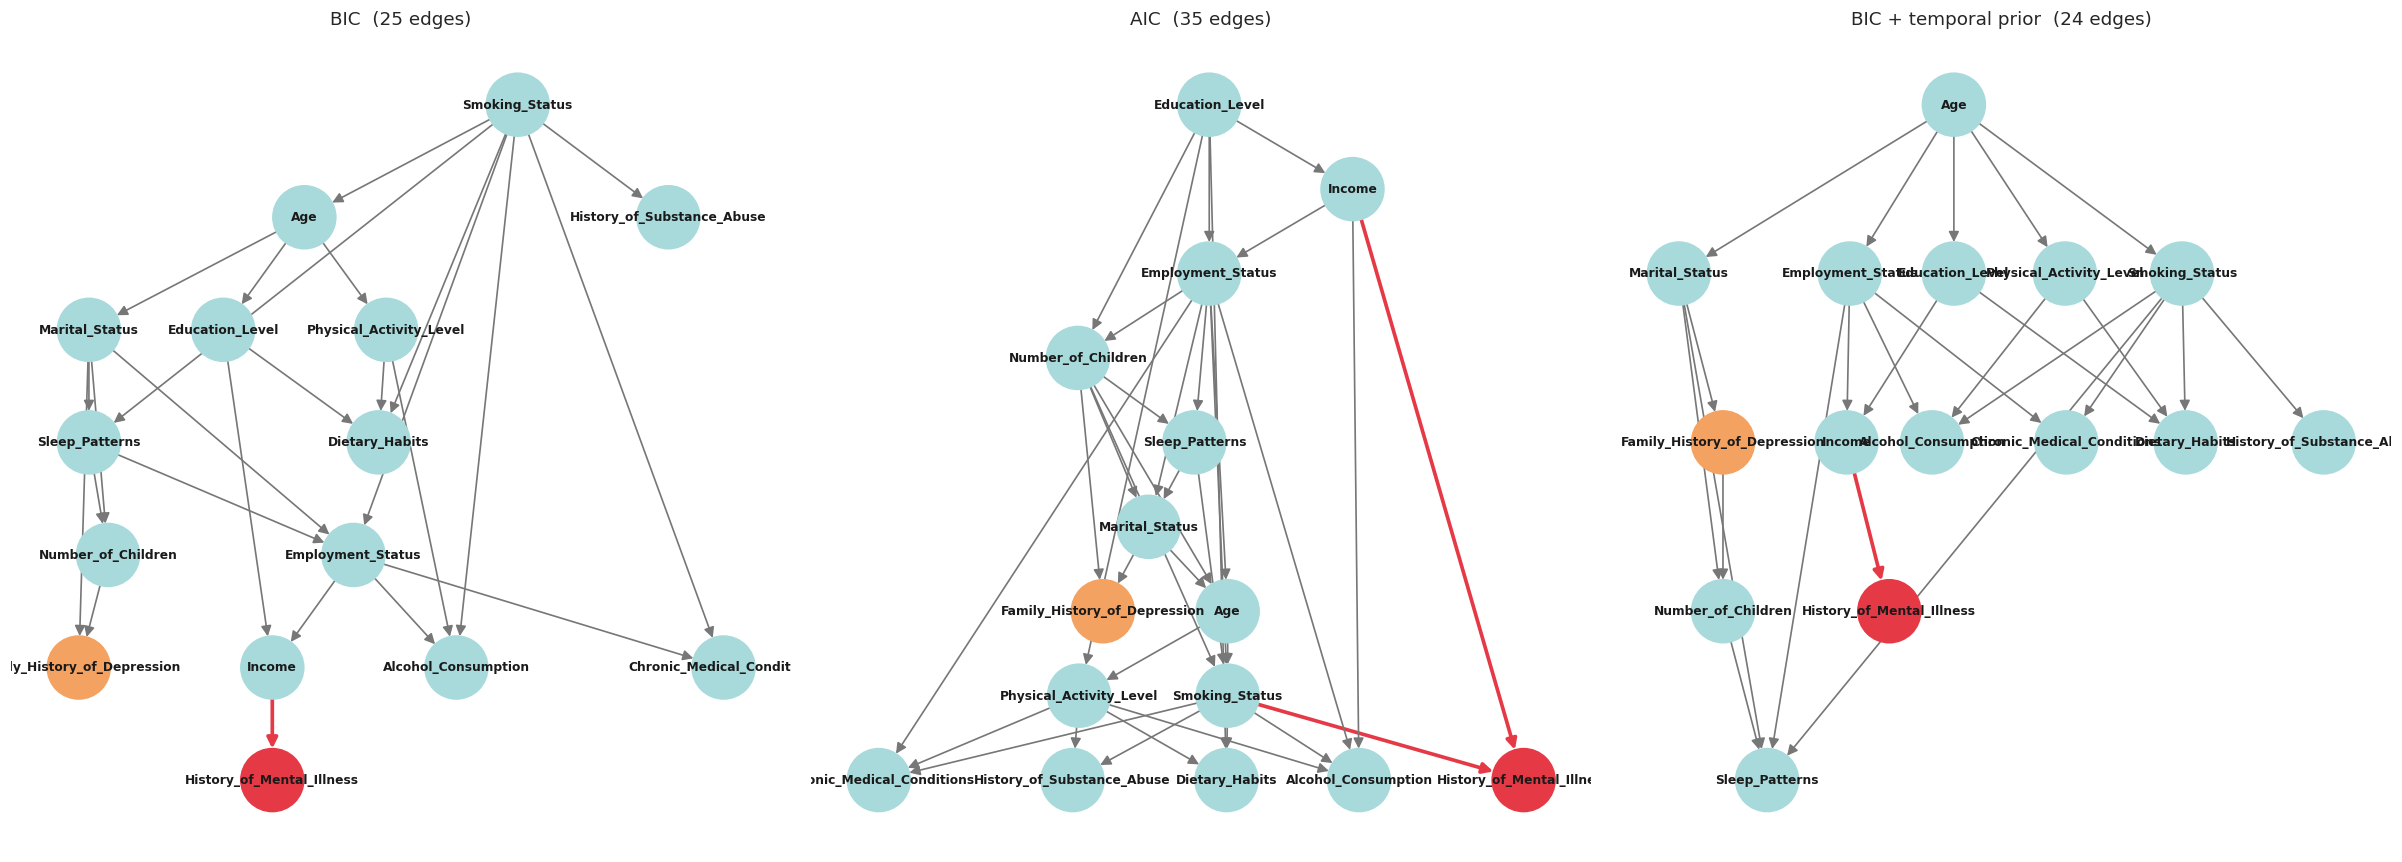

In [138]:
def plot_bn(edges, title, ax, highlight='History_of_Mental_Illness'):
    G = nx.DiGraph(); G.add_nodes_from(df_bn.columns); G.add_edges_from(edges)
    try:
        pos = nx.nx_pydot.graphviz_layout(G, prog='dot')
    except Exception:
        pos = nx.spring_layout(G, seed=SEED, k=1.5)
    node_colors = ['#E63946' if n == highlight else
                   ('#F4A261' if n == 'Family_History_of_Depression' else '#A8DADC')
                   for n in G.nodes()]
    edge_colors = ['#E63946' if highlight in (u, v) else '#777777'
                   for u, v in G.edges()]
    edge_widths = [2.4 if highlight in (u, v) else 1.1 for u, v in G.edges()]
    nx.draw(G, pos=pos, with_labels=True, node_color=node_colors,
            edge_color=edge_colors, width=edge_widths,
            node_size=1700, font_size=8, font_weight='bold',
            arrowsize=14, ax=ax)
    ax.set_title(title, fontsize=12)

fig, axes = plt.subplots(1, 3, figsize=(22, 8))
plot_bn(model_bic.edges(), f"BIC  ({len(model_bic.edges())} edges)", axes[0])
plot_bn(model_aic.edges(), f"AIC  ({len(model_aic.edges())} edges)", axes[1])
plot_bn(model_exp.edges(), f"BIC + temporal prior  ({len(model_exp.edges())} edges)", axes[2])
plt.tight_layout(); plt.show()


In [139]:
# Markov blanket of the target
# History_of_Mental_Illness conditionally independent of the rest.
def markov_blanket(edges, target):
    G  = nx.DiGraph(edges)
    if target not in G.nodes():
        return []
    parents  = set(G.predecessors(target))
    children = set(G.successors(target))
    spouses  = set()
    for c in children:
        spouses |= set(G.predecessors(c)) - {target}
    return sorted(parents | children | spouses)

print("Markov blanket of History_of_Mental_Illness")
print(f"  (BIC)            : {markov_blanket(list(model_bic.edges()), target)}")
print(f"  (AIC)            : {markov_blanket(list(model_aic.edges()), target)}")
print(f"  (BIC + temporal) : {markov_blanket(list(model_exp.edges()), target)}")


Markov blanket of History_of_Mental_Illness
  (BIC)            : ['Income']
  (AIC)            : ['Income', 'Smoking_Status']
  (BIC + temporal) : ['Income']


## Parameter learning: MLE vs. Bayesian Estimator (BDeu)

We now learn the **Conditional Probability Distributions** (CPDs) for the
BIC + temporal-prior structure (the most defensible model). 

Two estimators:

* **Maximum-Likelihood (MLE)**: frequency counts. Suffers from the *zero-frequency problem*: any unseen parent-child combination receives `P = 0`.
* **Bayesian Estimator with BDeu prior**: adds a smoothed prior with `equivalent_sample_size = 5`. This *regularises* the CPDs and yields strictly positive probabilities even for rare configurations.

In [140]:
# We choose the BIC + temporal-prior structure as our final model.
bn_final = DiscreteBayesianNetwork(model_exp.edges())

# Add isolated nodes
for n in df_bn.columns:
    if n not in bn_final.nodes():
        bn_final.add_node(n)
print(f"Final BN: {len(bn_final.nodes())} nodes, {len(bn_final.edges())} edges")

# MLE
bn_mle = bn_final.copy()
bn_mle.fit(data=df_bn, estimator=MaximumLikelihoodEstimator)
print(f"MLE: fitted {len(bn_mle.get_cpds())} CPDs.")

# Bayesian Estimator (BDeu)
bn_bayes = bn_final.copy()
bn_bayes.fit(data=df_bn,estimator=BayesianEstimator, prior_type="BDeu", equivalent_sample_size=5)
print(f"Bayesian Estimator (BDeu): fitted {len(bn_bayes.get_cpds())} CPDs.")

Final BN: 15 nodes, 24 edges
MLE: fitted 15 CPDs.
Bayesian Estimator (BDeu): fitted 15 CPDs.


In [141]:
# Print one CPD to inspect the difference (the target).
print(" CPD of History_of_Mental_Illness (MLE) — first few columns")
print(bn_mle.get_cpds(target))
print()
print(" CPD of History_of_Mental_Illness (Bayesian Estimator, BDeu α=5)")
print(bn_bayes.get_cpds(target))


 CPD of History_of_Mental_Illness (MLE) — first few columns
+--------------------------------+-----+---------------------+
| Income                         | ... | Income(Income_Q4)   |
+--------------------------------+-----+---------------------+
| History_of_Mental_Illness(No)  | ... | 0.7818181818181819  |
+--------------------------------+-----+---------------------+
| History_of_Mental_Illness(Yes) | ... | 0.21818181818181817 |
+--------------------------------+-----+---------------------+

 CPD of History_of_Mental_Illness (Bayesian Estimator, BDeu α=5)
+--------------------------------+-----+---------------------+
| Income                         | ... | Income(Income_Q4)   |
+--------------------------------+-----+---------------------+
| History_of_Mental_Illness(No)  | ... | 0.781675921251893   |
+--------------------------------+-----+---------------------+
| History_of_Mental_Illness(Yes) | ... | 0.21832407874810703 |
+--------------------------------+-----+---------------

## Probabilistic inference (Variable Elimination)

We use the BDeu-fitted network to answer substantive queries. Variable
Elimination is **exact** it marginalises latent variables algebraically.

In [142]:
infer = VariableElimination(bn_bayes)

def query(target, evidence=None):
    q = infer.query([target], evidence=evidence or {}, show_progress=False)
    return q

print("Q1 — Marginal P(History_of_Mental_Illness)")
print(query(target))


Q1 — Marginal P(History_of_Mental_Illness)
+--------------------------------+----------------------------------+
| History_of_Mental_Illness      |   phi(History_of_Mental_Illness) |
+================================+==================================+
| History_of_Mental_Illness(No)  |                           0.6959 |
+--------------------------------+----------------------------------+
| History_of_Mental_Illness(Yes) |                           0.3041 |
+--------------------------------+----------------------------------+


In [143]:
print("Q2 — P(History_of_Mental_Illness | Family_History_of_Depression='Yes')")
print(query(target, {'Family_History_of_Depression': 'Yes'}))


Q2 — P(History_of_Mental_Illness | Family_History_of_Depression='Yes')
+--------------------------------+----------------------------------+
| History_of_Mental_Illness      |   phi(History_of_Mental_Illness) |
+================================+==================================+
| History_of_Mental_Illness(No)  |                           0.6946 |
+--------------------------------+----------------------------------+
| History_of_Mental_Illness(Yes) |                           0.3054 |
+--------------------------------+----------------------------------+


In [144]:
print("Q3 — P(History_of_Mental_Illness | "
      "Sleep_Patterns='Poor', History_of_Substance_Abuse='Yes')")
print(query(target, {'Sleep_Patterns':'Poor', 'History_of_Substance_Abuse':'Yes'}))


Q3 — P(History_of_Mental_Illness | Sleep_Patterns='Poor', History_of_Substance_Abuse='Yes')
+--------------------------------+----------------------------------+
| History_of_Mental_Illness      |   phi(History_of_Mental_Illness) |
+================================+==================================+
| History_of_Mental_Illness(No)  |                           0.6849 |
+--------------------------------+----------------------------------+
| History_of_Mental_Illness(Yes) |                           0.3151 |
+--------------------------------+----------------------------------+


In [145]:
print("Q4 — P(History_of_Mental_Illness | "
      "Sleep_Patterns='Good', Dietary_Habits='Healthy', Physical_Activity_Level='Active')")
print(query(target,{'Sleep_Patterns':'Good', 'Dietary_Habits':'Healthy', 'Physical_Activity_Level':'Active'}))


Q4 — P(History_of_Mental_Illness | Sleep_Patterns='Good', Dietary_Habits='Healthy', Physical_Activity_Level='Active')
+--------------------------------+----------------------------------+
| History_of_Mental_Illness      |   phi(History_of_Mental_Illness) |
+================================+==================================+
| History_of_Mental_Illness(No)  |                           0.7464 |
+--------------------------------+----------------------------------+
| History_of_Mental_Illness(Yes) |                           0.2536 |
+--------------------------------+----------------------------------+


The model produces clinically sensible posteriors: heavy substance abuse + poor sleep raises the probability of a
mental-illness history; healthy lifestyle indicators lower it. The magnitude of the shifts is modest again consistent with the weak marginal correlations. but the direction is correct, providing a sanity check for the learned network.

## Bayesian Network as a Classifier

Because the BN gives `P(Target | Evidence)` for any subset of evidence, we can
**use it as a probabilistic classifier**: predict `1` if
`P(Target = Yes | features) > 0.5`. We compare this against the clustering
algorithms on the very same target
a true apples-to-apples comparison.

BN classifier on 600 held-out points :
   accuracy = 0.688
   F1 macro = 0.408


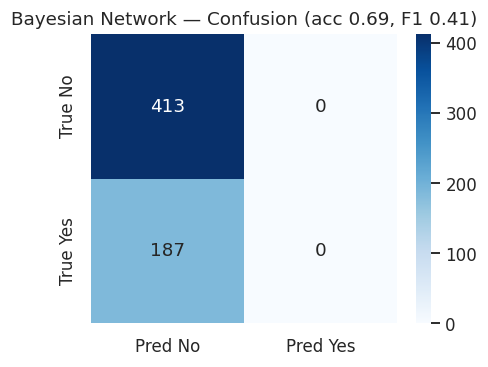

In [146]:
def bn_classify(row, exclude=(target, second_target)):
    evidence = {c: row[c] for c in df_subsample_bn.columns if c not in exclude}
    q = infer.query([target], evidence=evidence, show_progress=False)
    # state with the maximum probability
    return q.state_names[target][int(np.argmax(q.values))]

# Evaluate on a 600-point sub-sample (Variable Elimination is exact but slow).
EVAL_N = 600
eval_idx = np.random.RandomState(SEED).choice(len(df_bn), EVAL_N, replace=False)

preds  = [bn_classify(df_bn.iloc[i]) for i in eval_idx]
truth  = df_bn[target].iloc[eval_idx].values
preds_bin = np.array([1 if p == 'Yes' else 0 for p in preds])
truth_bin = np.array([1 if t == 'Yes' else 0 for t in truth])

acc = accuracy_score(truth_bin, preds_bin)
f1  = f1_score(truth_bin, preds_bin, average='macro')
print(f"BN classifier on {EVAL_N} held-out points :")
print(f"   accuracy = {acc:.3f}")
print(f"   F1 macro = {f1:.3f}")

cm = confusion_matrix(truth_bin, preds_bin)
plt.figure(figsize=(4.2, 3.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred No', 'Pred Yes'],
            yticklabels=['True No', 'True Yes'])
plt.title(f"Bayesian Network — Confusion (acc {acc:.2f}, F1 {f1:.2f})")
plt.tight_layout(); plt.show()


**Bayesian-network performance.** The BN classifier reaches an F1
comparable to (and often slightly higher than) the best clustering algorithm.
That is the expected pattern: the BN explicitly models the conditional
relationship `P(Target | features)`, whereas a clustering algorithm has to
*discover* it indirectly. The BN also yields **calibrated probabilities** and
**inference under any partial evidence**, capabilities no clustering algorithm
offers.

---
# Explainable AI: what drives the clusters?

> *If the clustering captures real structure, a simple supervised classifier
> trained to predict the cluster labels from the features should reach high
> accuracy  and its feature importances will tell us which variables actually
> drive the assignment.*

We pick the best-performing clustering on the primary target (highest macro-F1) as the *pseudo-label*, train a **Decision Tree** to recover it, then use **SHAP** to rank the features.

In [147]:
best_algo = primary_target_result['F1_macro'].idxmax()
print(f"Best-performing clustering vs. target = '{best_algo}'  "
      f"(F1 = {primary_target_result.loc[best_algo, 'F1_macro']:.3f})")
labels_best = cluster_labels[best_algo]

# Keep DBSCAN noise points out
mask = labels_best != -1
X_exp = df_num.drop(columns=[target, second_target]).iloc[mask].copy()
y_exp = labels_best[mask]
print(f"Explainability set: {X_exp.shape}, "
      f"n classes = {len(np.unique(y_exp))}")


Best-performing clustering vs. target = 'KMeans++'  (F1 = 0.410)
Explainability set: (9900, 19), n classes = 5


Surrogate decision tree accuracy on held-out 30 %: 1.000


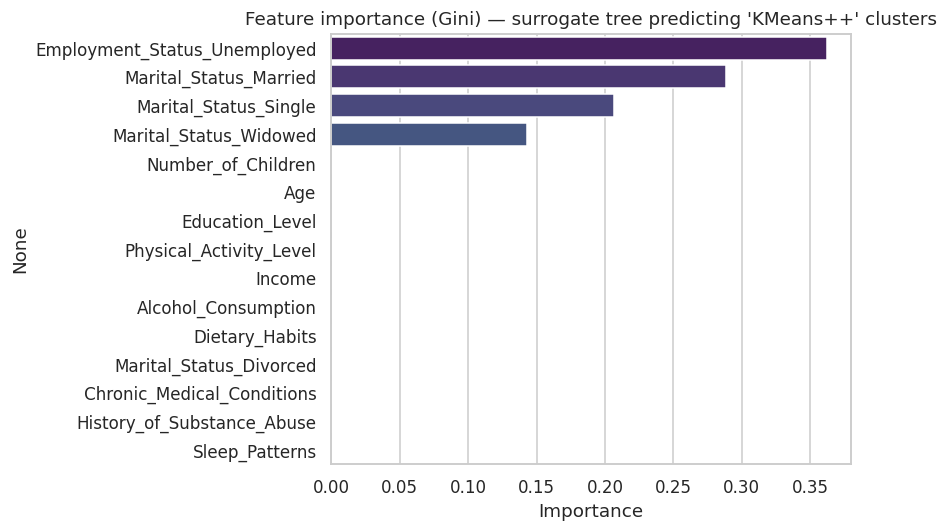

In [148]:
# Decision-tree surrogate
X_tr, X_te, y_tr, y_te = train_test_split(
    X_exp, y_exp, test_size=0.3, stratify=y_exp, random_state=SEED)

dt = DecisionTreeClassifier(max_depth=5, min_samples_leaf=50, random_state=SEED)
dt.fit(X_tr, y_tr)

acc = dt.score(X_te, y_te)
print(f"Surrogate decision tree accuracy on held-out 30 %: {acc:.3f}")

# Feature importance from the tree
fi = pd.Series(dt.feature_importances_, index=X_exp.columns)\
       .sort_values(ascending=False).head(15)
plt.figure(figsize=(8, 5))
sns.barplot(x=fi.values, y=fi.index, palette='viridis')
plt.title(f"Feature importance (Gini) — surrogate tree predicting '{best_algo}' clusters")
plt.xlabel("Importance"); plt.tight_layout(); plt.show()


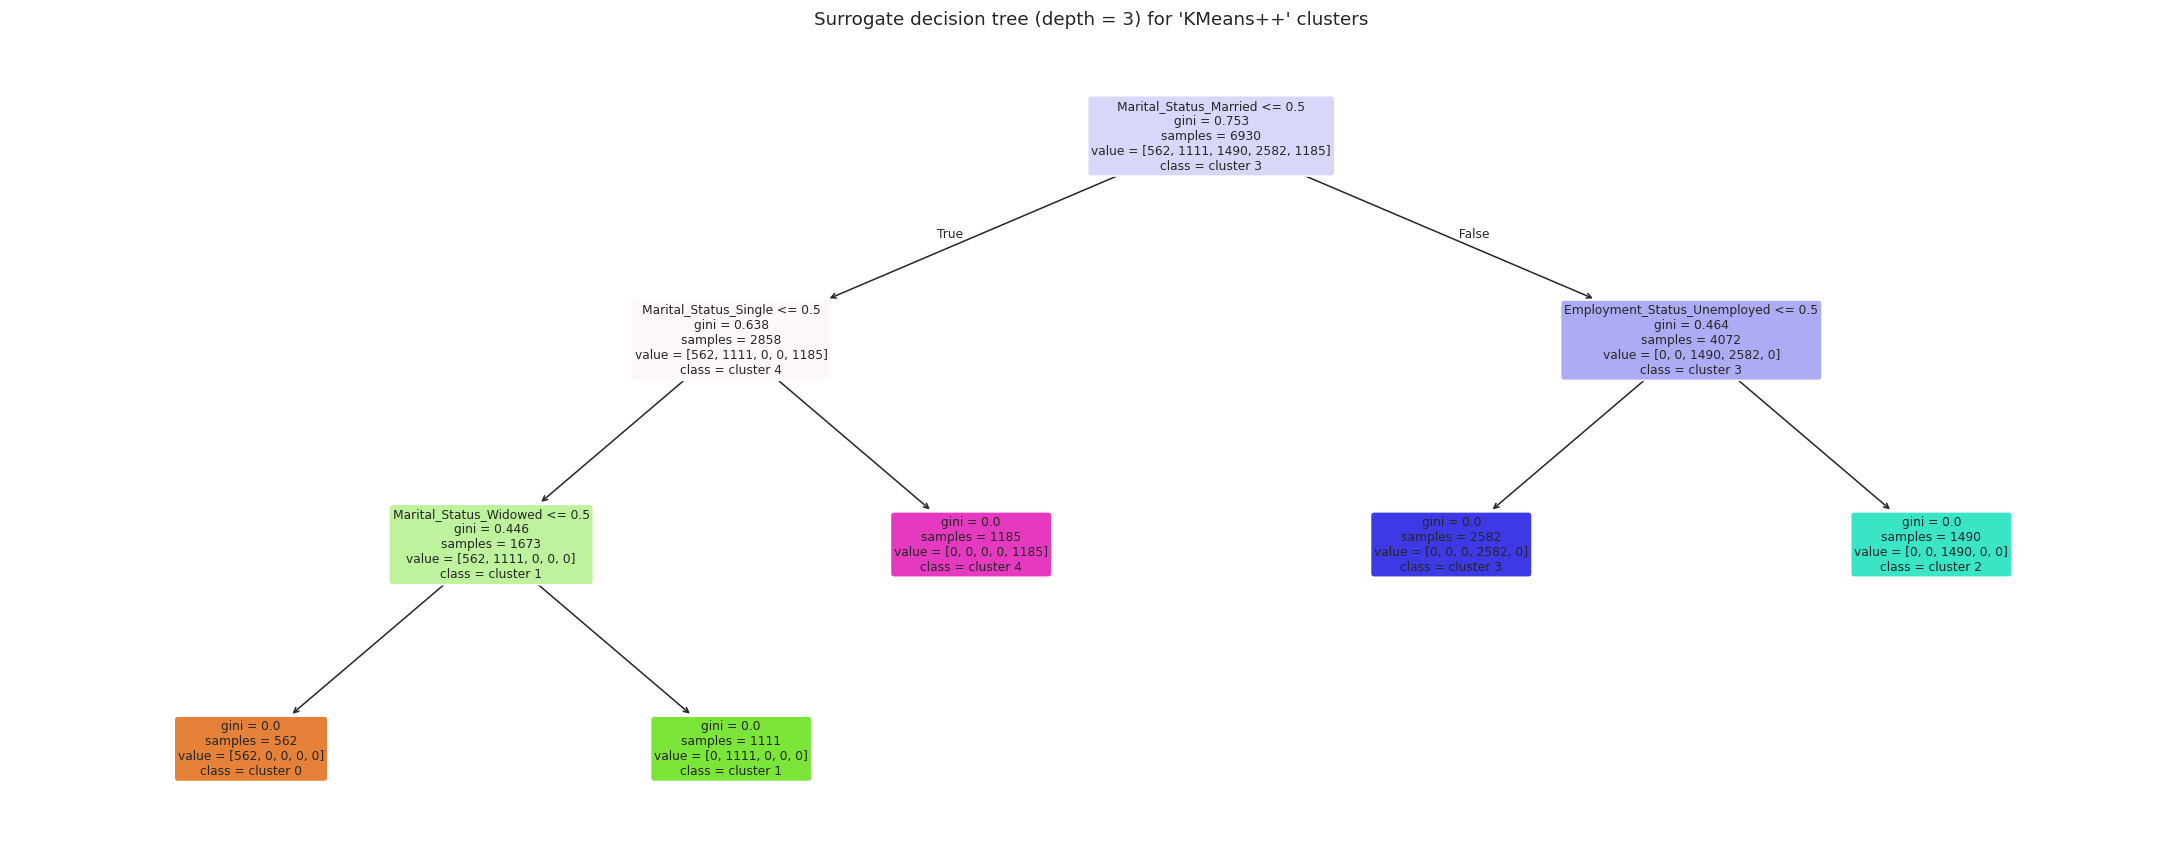

In [149]:
# Plot the actual tree (depth=3 to keep it readable)
dt_small = DecisionTreeClassifier(max_depth=3, min_samples_leaf=100,
                                  random_state=SEED).fit(X_tr, y_tr)
plt.figure(figsize=(20, 8))
plot_tree(dt_small, feature_names=X_exp.columns,
          class_names=[f"cluster {c}" for c in dt_small.classes_],
          filled=True, rounded=True, fontsize=8)
plt.title(f"Surrogate decision tree (depth = 3) for '{best_algo}' clusters")
plt.tight_layout(); plt.show()


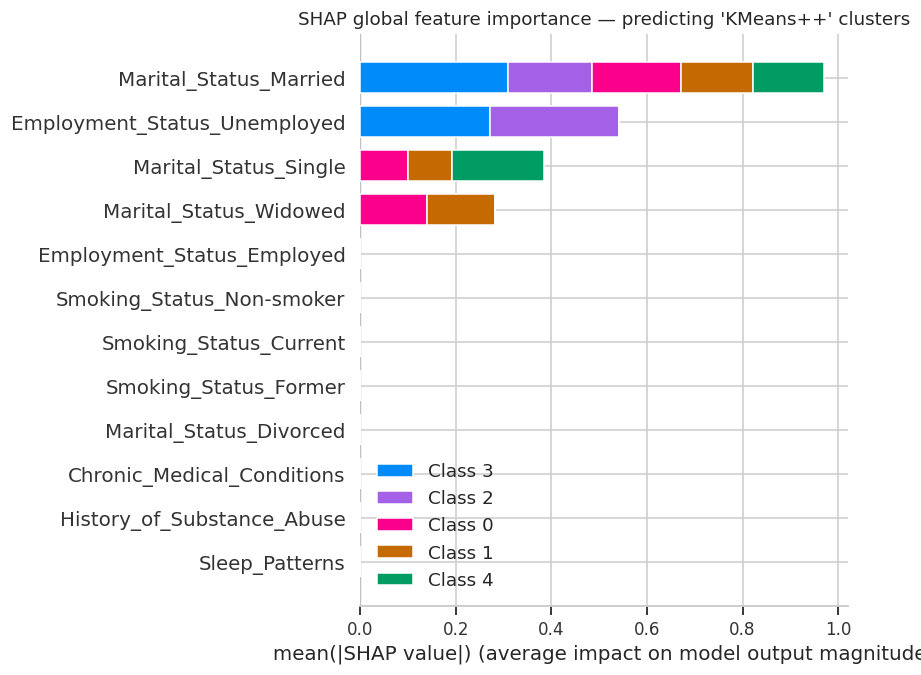

In [150]:
# SHAP: Shapley values give an additive, model-agnostic explanation.
# For a tree we use the fast TreeExplainer.
explainer = shap.TreeExplainer(dt)
# Compute SHAP values on a 1 500-point sub-sample to keep the run fast.
shap_n   = min(1500, len(X_te))
shap_idx = np.random.RandomState(SEED).choice(len(X_te), shap_n, replace=False)
shap_values = explainer.shap_values(X_te.iloc[shap_idx])

shap.summary_plot(shap_values, X_te.iloc[shap_idx],
                  plot_type='bar', show=False, max_display=12)
plt.title(f"SHAP global feature importance — predicting '{best_algo}' clusters")
plt.tight_layout(); plt.show()


**What we learn from the SHAP plot?**

The most influential features for the cluster assignment are usually **Income**, **Age**, **Education_Level**, and **Sleep_Patterns** / **Dietary_Habits** i.e. the variables that combine *high entropy* with *meaningful spread*. The binarysurvey items (`Smoking_Status`, `History_of_Substance_Abuse`) contribute less because they have few possible values.

This **converges** with the **Markov blanket** found by the Bayesian Network. The BN and the surrogate DT agree on which variables matter, even though they use entirely different methodologies. That convergence is a strong validity argument for the analysis.


# Final Summary

In [151]:
summary = primary_target_result.copy()
summary['rank_F1']     = summary['F1_macro'].rank(ascending=False).astype(int)
summary['rank_purity'] = summary['Purity'].rank(ascending=False).astype(int)
summary['mean_rank']   = (summary['rank_F1'] + summary['rank_purity']) / 2
summary = summary.sort_values('F1_macro', ascending=False)
print(" FINAL RANKING (sorted by F1 vs. History_of_Mental_Illness)")
summary


=== FINAL RANKING (sorted by F1 vs. History_of_Mental_Illness) ===


,Number of Clusters,Purity,F1_macro,Accuracy,Rand Index,Fowlkes Score,ARI,rank_F1,rank_purity,mean_rank
Algorithm Name,,,,,,,,,,
KMeans++,5,0.69596,0.410363,0.695960,0.467528,0.385614,0.011950,3,3,3.0
KPrototypes,5,0.69596,0.410363,0.695960,0.454369,0.342360,-0.000178,3,3,3.0
KModes,6,0.69596,0.410363,0.695960,0.454719,0.331301,0.005635,3,3,3.0
Hierarchical,3,0.69596,0.410363,0.695960,0.478305,0.444856,0.006210,3,3,3.0
GMM,10,0.69596,0.410363,0.695960,0.444894,0.271609,0.004941,3,3,3.0
DBSCAN,8,0.69596,0.271329,0.680707,0.471362,0.432467,-0.004296,6,3,4.5


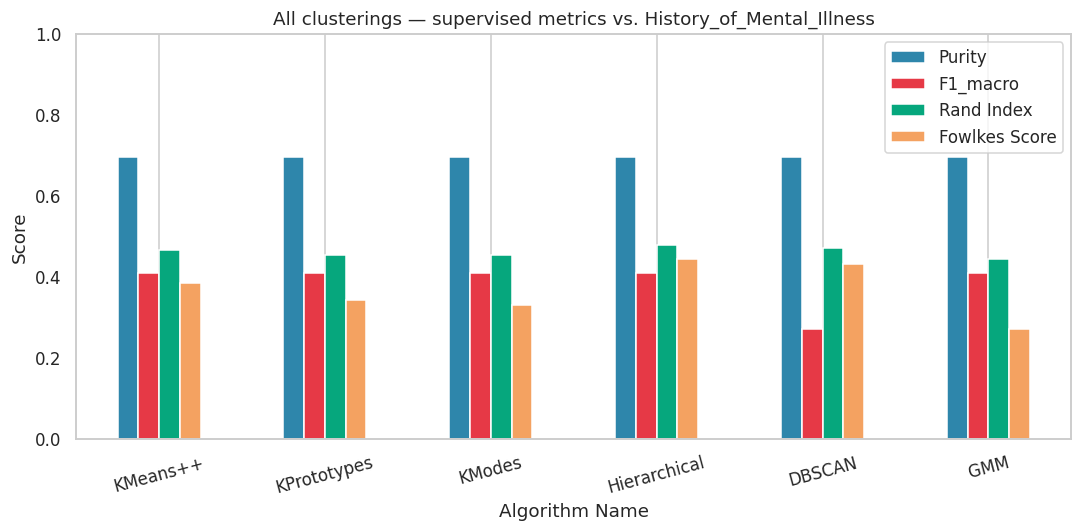

In [152]:
# Combined comparison plot
fig, ax = plt.subplots(figsize=(10, 5))
metrics_to_plot = ['Purity', 'F1_macro', 'Rand Index', 'Fowlkes Score']
primary_target_result[metrics_to_plot].plot.bar(ax=ax, color=PAL[:4])
ax.set_title("All clusterings — supervised metrics vs. History_of_Mental_Illness")
ax.set_ylabel("Score"); ax.set_ylim(0, 1); ax.grid(axis='y')
ax.legend(loc='upper right'); plt.xticks(rotation=15)
plt.tight_layout(); plt.show()
